# Case Study: End-to-End ML Project (3 Small Case Studies - Advanced)

## 1. Regression: Energy Consumption Forecasting

### 1.1 Problem Statement and Business Context

Accurate energy consumption forecasting is critical for power grid management, energy trading, and sustainability planning. In this case study, we'll build a model to predict hourly energy consumption for a commercial building, helping facility managers optimize energy usage and reduce costs.

In [1]:
# !pip install prophet
# !pip install holidays

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import lightgbm as lgb
import holidays
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('fivethirtyeight')
sns.set_palette('viridis')

### 1.2 Dataset Description and Loading

We'll use the Building Energy Consumption dataset which contains years of energy consumption data along with weather and temporal features.

In [3]:
# Load the dataset (using a URL or local file)
energy_data = pd.read_csv('building_energy_data.csv', parse_dates=['timestamp'])

# Set timestamp as index
energy_data.set_index('timestamp', inplace=True)

# Display basic information
print(f"Dataset shape: {energy_data.shape}")
print(f"Date range: {energy_data.index.min()} to {energy_data.index.max()}")
print(f"Missing values: {energy_data.isnull().sum().sum()}")

# Preview the data
print("\nData preview:")
print(energy_data.head())

# Summary statistics
print("\nSummary statistics:")
print(energy_data.describe())

Dataset shape: (17520, 4)
Date range: 2021-01-01 00:00:00 to 2022-12-31 23:00:00
Missing values: 0

Data preview:
                     outdoor_temperature   humidity  occupancy  \
timestamp                                                        
2021-01-01 00:00:00            10.101548  31.553341   0.290471   
2021-01-01 01:00:00            12.444014  48.556798   0.189441   
2021-01-01 02:00:00            14.669119  67.169386   0.210637   
2021-01-01 03:00:00             5.419474  60.634946   0.140232   
2021-01-01 04:00:00            13.969947  50.327779   0.298341   

                     energy_consumption  
timestamp                                
2021-01-01 00:00:00           75.770463  
2021-01-01 01:00:00           82.353470  
2021-01-01 02:00:00           60.038518  
2021-01-01 03:00:00           86.711008  
2021-01-01 04:00:00           60.393145  

Summary statistics:
       outdoor_temperature      humidity     occupancy  energy_consumption
count         17520.000000  17520

### 1.3 Exploratory Data Analysis

Let's explore the patterns in energy consumption and understand the factors affecting it.

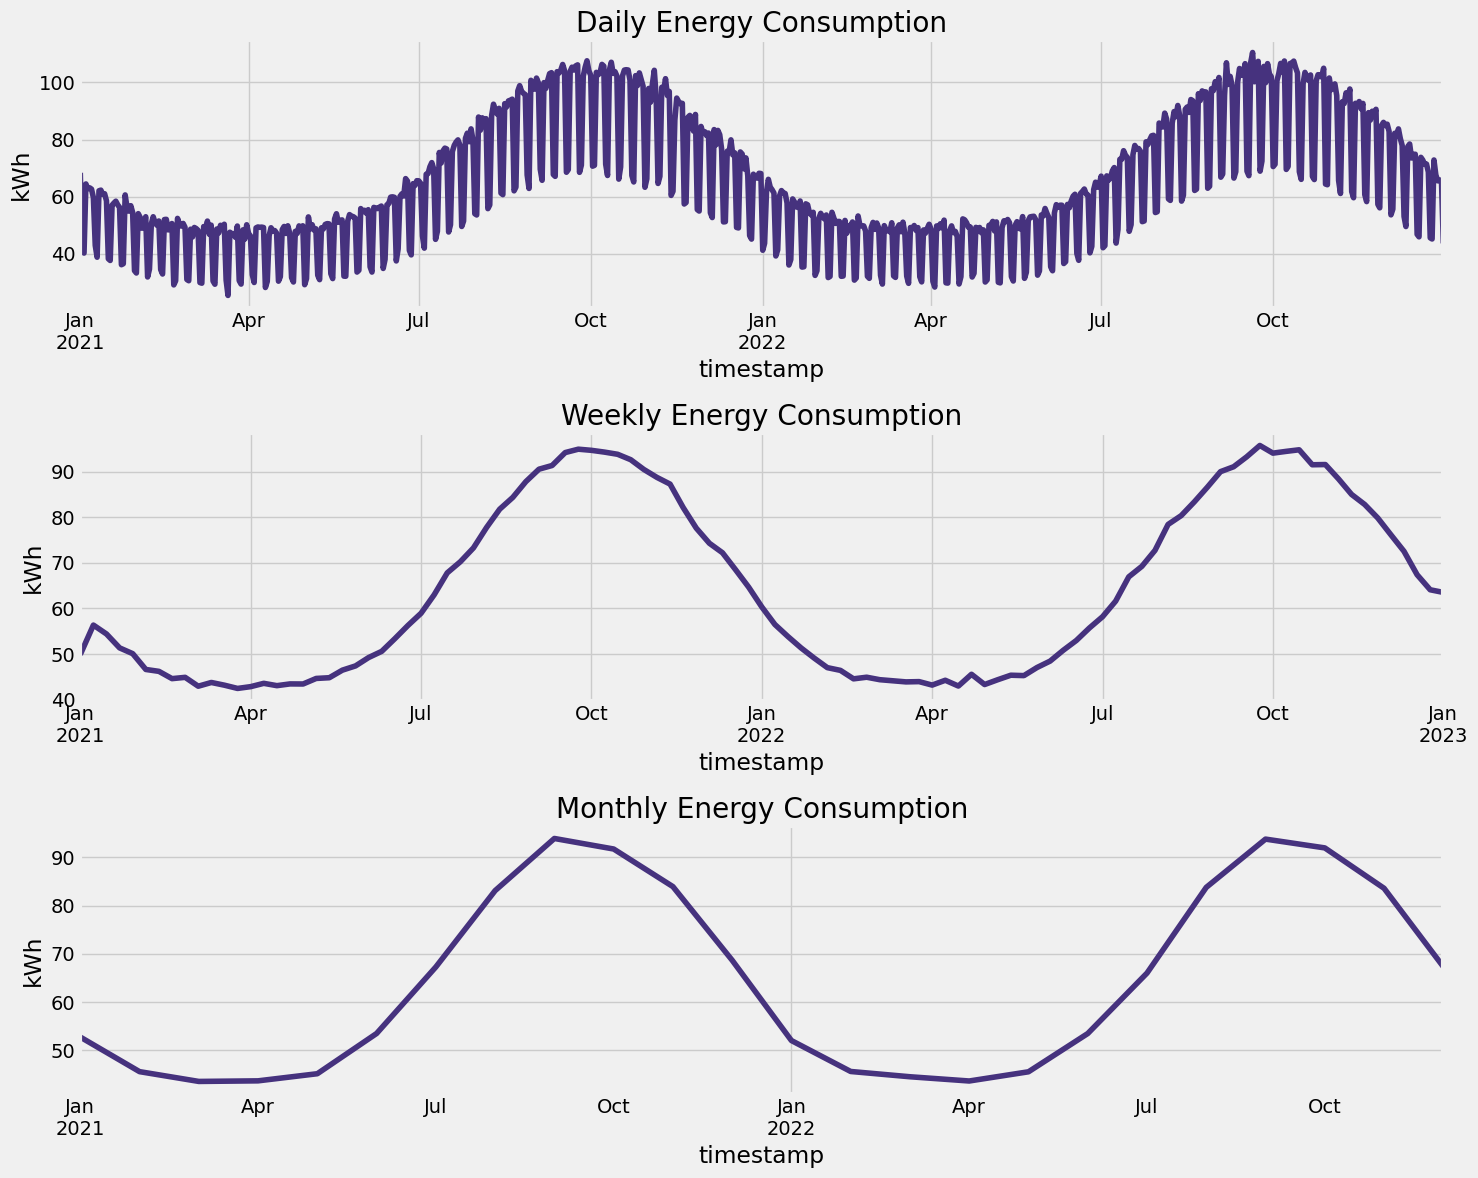

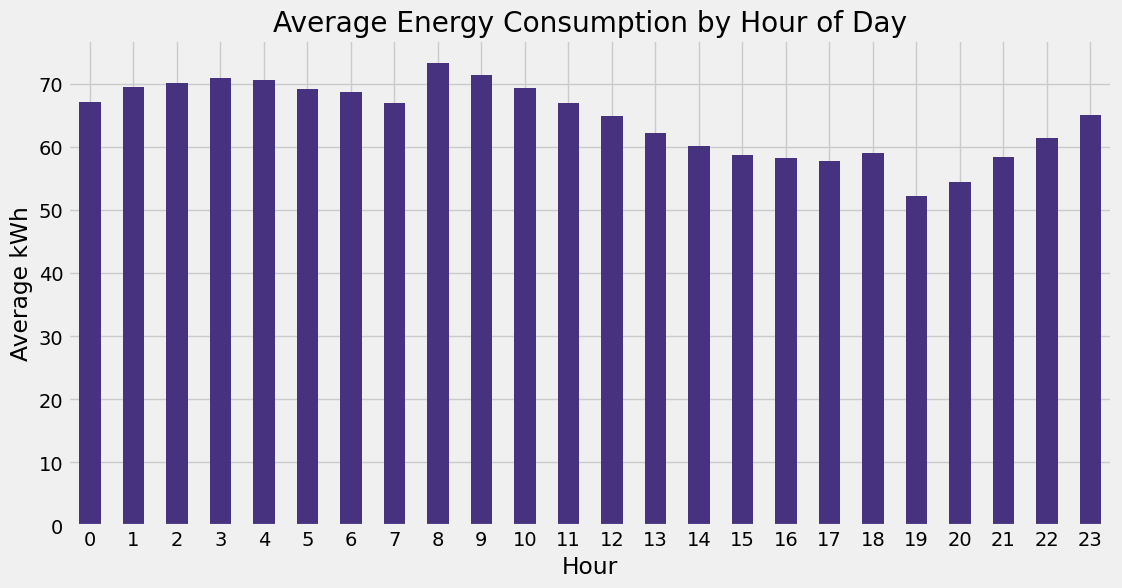

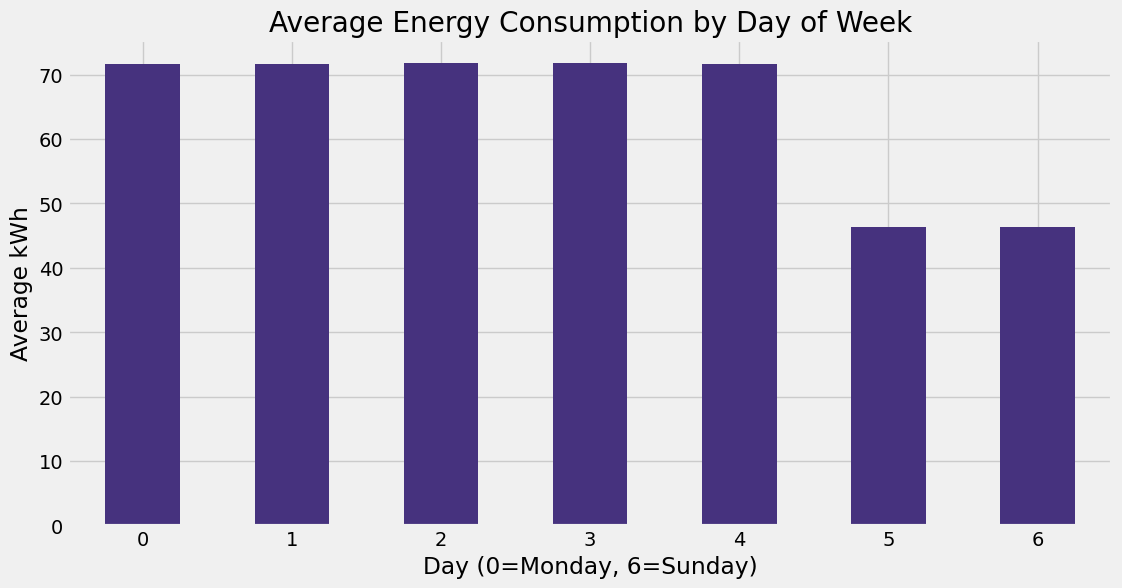

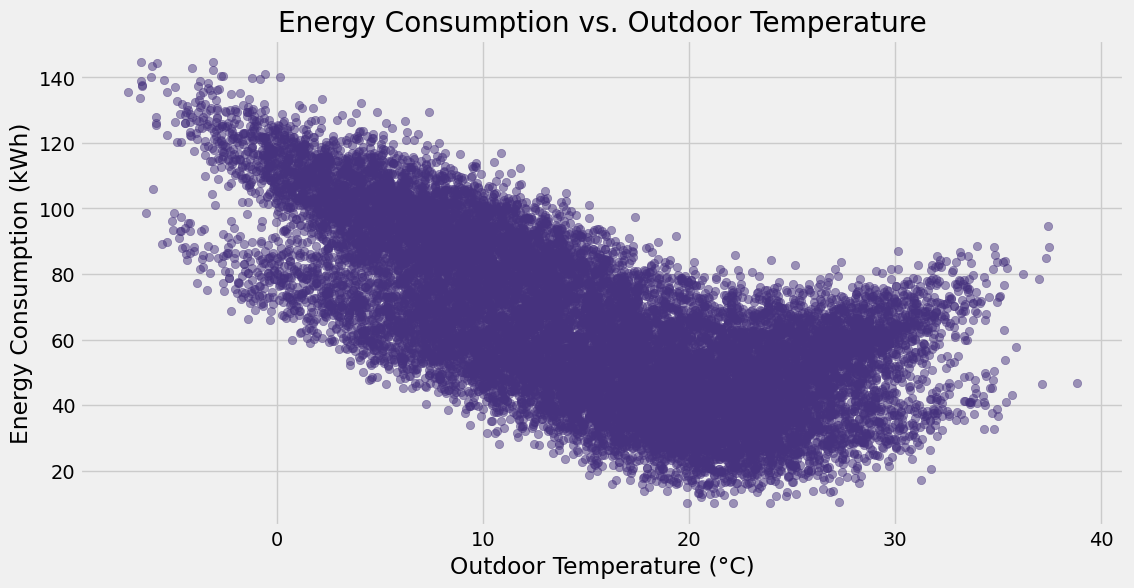

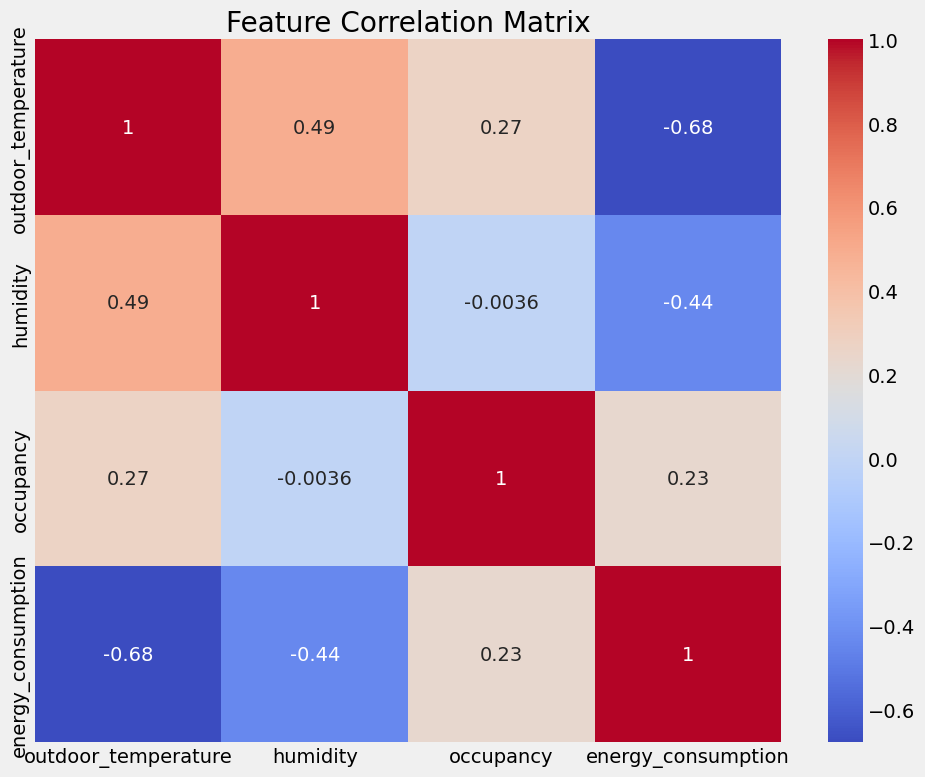

In [4]:
# Resample data to different time intervals
daily = energy_data['energy_consumption'].resample('D').mean()
weekly = energy_data['energy_consumption'].resample('W').mean()
monthly = energy_data['energy_consumption'].resample('M').mean()

# Plot time series at different intervals
plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
daily.plot()
plt.title('Daily Energy Consumption')
plt.ylabel('kWh')

plt.subplot(3, 1, 2)
weekly.plot()
plt.title('Weekly Energy Consumption')
plt.ylabel('kWh')

plt.subplot(3, 1, 3)
monthly.plot()
plt.title('Monthly Energy Consumption')
plt.ylabel('kWh')

plt.tight_layout()
plt.show()

# Analyze seasonality: hourly patterns
plt.figure(figsize=(12, 6))
hourly_avg = energy_data.groupby(energy_data.index.hour)['energy_consumption'].mean()
hourly_avg.plot(kind='bar')
plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average kWh')
plt.xticks(rotation=0)
plt.show()

# Analyze seasonality: daily patterns
plt.figure(figsize=(12, 6))
daily_avg = energy_data.groupby(energy_data.index.dayofweek)['energy_consumption'].mean()
daily_avg.plot(kind='bar')
plt.title('Average Energy Consumption by Day of Week')
plt.xlabel('Day (0=Monday, 6=Sunday)')
plt.ylabel('Average kWh')
plt.xticks(rotation=0)
plt.show()

# Analyze relationship with temperature
plt.figure(figsize=(12, 6))
plt.scatter(energy_data['outdoor_temperature'], energy_data['energy_consumption'], alpha=0.5)
plt.title('Energy Consumption vs. Outdoor Temperature')
plt.xlabel('Outdoor Temperature (°C)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

# Calculate correlation matrix
plt.figure(figsize=(10, 8))
correlation = energy_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 1.4 Feature Engineering

For energy forecasting, we need to create rich temporal features and account for seasonality.

In [5]:
# Create a copy of the dataframe
df = energy_data.copy()

# Temporal features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
df['week_of_year'] = df.index.isocalendar().week
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# US holidays
us_holidays = holidays.US()
df['is_holiday'] = df.index.map(lambda x: x in us_holidays).astype(int)

# Time of day categories
df['time_of_day'] = pd.cut(
    df['hour'], 
    bins=[0, 6, 12, 18, 24], 
    labels=['night', 'morning', 'afternoon', 'evening'],
    include_lowest=True
)
df = pd.get_dummies(df, columns=['time_of_day'])

# Cyclical encoding for hour, day of week, month
def encode_cyclical(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

df = encode_cyclical(df, 'hour', 24)
df = encode_cyclical(df, 'day_of_week', 7)
df = encode_cyclical(df, 'month', 12)

# Lag features (previous hours)
for i in [1, 2, 3, 6, 12, 24]:
    df[f'energy_lag_{i}'] = df['energy_consumption'].shift(i)

# Rolling mean features
for window in [3, 6, 12, 24]:
    df[f'rolling_mean_{window}h'] = df['energy_consumption'].rolling(window=window).mean()
    
# Temperature features
df['temp_squared'] = df['outdoor_temperature'] ** 2  # For non-linear relationships
df['heating_degree'] = np.maximum(18.5 - df['outdoor_temperature'], 0)  # Heating threshold 18.5°C
df['cooling_degree'] = np.maximum(df['outdoor_temperature'] - 21, 0)   # Cooling threshold 21°C

# Drop missing values created by lag and rolling features
df.dropna(inplace=True)

print(f"Original dataset shape: {energy_data.shape}")
print(f"Processed dataset shape: {df.shape}")

Original dataset shape: (17520, 4)
Processed dataset shape: (17496, 35)


### 1.5 Model Development

Let's implement multiple models for comparison.

Training set size: (13996, 34)
Testing set size: (3500, 34)
ARIMA Performance:
RMSE: 14.90
MAE: 12.07
R² Score: 0.5144
MAPE: 14.79%



11:19:03 - cmdstanpy - INFO - Chain [1] start processing
11:19:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet Performance:
RMSE: 11.53
MAE: 9.17
R² Score: 0.7092
MAPE: 11.98%

XGBoost Performance:
RMSE: 3.17
MAE: 2.35
R² Score: 0.9780
MAPE: 2.77%

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4551
[LightGBM] [Info] Number of data points in the train set: 13996, number of used features: 34
[LightGBM] [Info] Start training from score 59.472713
LightGBM Performance:
RMSE: 3.07
MAE: 2.28
R² Score: 0.9794
MAPE: 2.68%

Model Performance Comparison:
      model       rmse        mae        r2       mape
3  LightGBM   3.065737   2.278363  0.979439   2.684529
2   XGBoost   3.168329   2.349773  0.978039   2.765671
1   Prophet  11.528476   9.173921  0.709245  11.984011
0     ARIMA  14.898645  12.070218  0.514402  14.789629


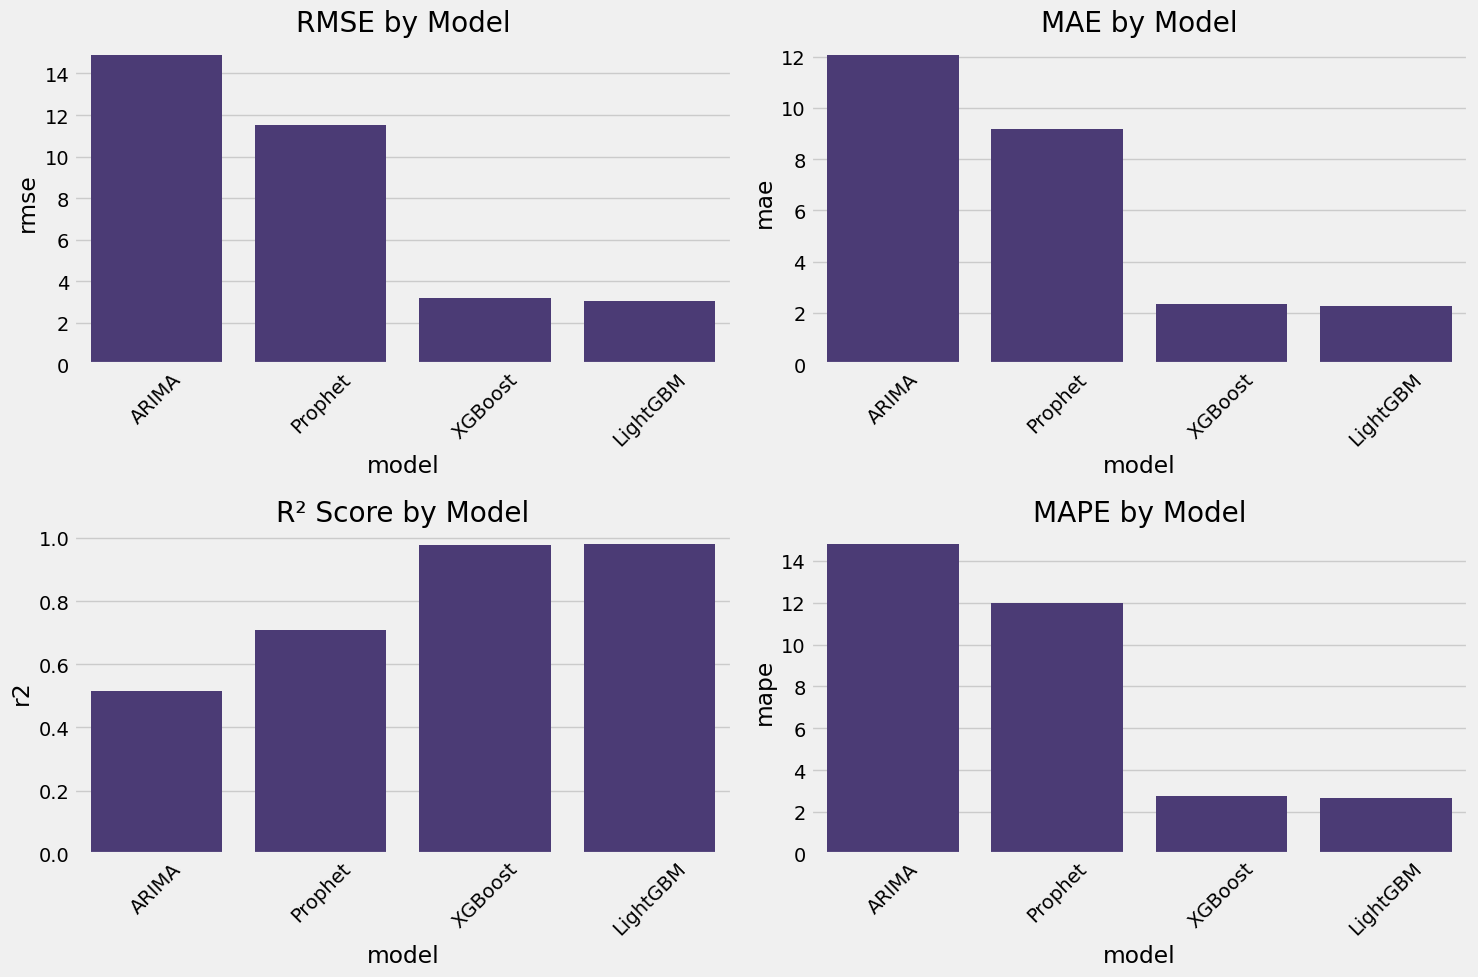

In [6]:
# Define features and target variable
X = df.drop('energy_consumption', axis=1)
y = df['energy_consumption']

# Split the data into training and testing sets
# Use a time-based split for time series data
train_end = int(len(df) * 0.8)
X_train, X_test = X[:train_end], X[train_end:]
y_train, y_test = y[:train_end], y[train_end:]

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Function to evaluate regression models
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"{model_name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%\n")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape
    }

# Store results for comparison
results = []

# 1. ARIMA Model
# Simplified approach with fixed parameters for illustration
arima_features = ['hour', 'is_weekend', 'outdoor_temperature']
arima_model = ARIMA(y_train, exog=X_train[arima_features], order=(3, 0, 3))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(X_test), exog=X_test[arima_features])
results.append(evaluate_model(y_test, arima_pred, "ARIMA"))

# 2. Prophet Model
# Extract key features for Prophet
prophet_df = pd.DataFrame({
    'ds': df.index[:train_end],
    'y': y_train,
    'temp': X_train['outdoor_temperature']
})
prophet_test = pd.DataFrame({
    'ds': df.index[train_end:],
    'temp': X_test['outdoor_temperature']
})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)
prophet_model.add_regressor('temp')
prophet_model.fit(prophet_df)

prophet_forecast = prophet_model.predict(prophet_test)
prophet_pred = prophet_forecast['yhat'].values
results.append(evaluate_model(y_test, prophet_pred, "Prophet"))

# 3. XGBoost Model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
results.append(evaluate_model(y_test, xgb_pred, "XGBoost"))

# 4. LightGBM Model
lgbm_model = lgb.LGBMRegressor(
    objective='regression',
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=300,
    random_state=42
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)
results.append(evaluate_model(y_test, lgbm_pred, "LightGBM"))

# Compare all models
results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df.sort_values('rmse'))

# Visualize model performance
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='model', y='rmse', data=results_df)
plt.title('RMSE by Model')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
sns.barplot(x='model', y='mae', data=results_df)
plt.title('MAE by Model')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.barplot(x='model', y='r2', data=results_df)
plt.title('R² Score by Model')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.barplot(x='model', y='mape', data=results_df)
plt.title('MAPE by Model')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 1.6 Model Interpretation and Feature Importance

In [7]:
# # Plot feature importance for XGBoost model
# plt.figure(figsize=(14, 10))
# feature_importance = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': xgb_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# # Top 20 features
# top_features = feature_importance.head(20)
# sns.barplot(x='Importance', y='Feature', data=top_features)
# plt.title('XGBoost Feature Importance')
# plt.tight_layout()
# plt.show()

# # Plot predictions vs actual values
# plt.figure(figsize=(16, 6))
# test_dates = df.index[train_end:]
# plt.plot(test_dates, y_test, label='Actual', alpha=0.7)
# plt.plot(test_dates, xgb_pred, label='XGBoost', alpha=0.7)
# plt.plot(test_dates, lgbm_pred, label='LightGBM', alpha=0.7)
# plt.title('Energy Consumption: Actual vs Predicted')
# plt.xlabel('Date')
# plt.ylabel('Energy Consumption (kWh)')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # SHAP values for XGBoost model (requires shap library)
# import shap
# explainer = shap.TreeExplainer(xgb_model)
# shap_values = explainer.shap_values(X_test.iloc[:100])  # Use a subset for faster rendering

# plt.figure(figsize=(12, 10))
# shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar")
# plt.title('SHAP Feature Importance')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 10))
# shap.summary_plot(shap_values, X_test.iloc[:100])
# plt.title('SHAP Summary Plot')
# plt.tight_layout()
# plt.show()

#### FIXED CODE (WORKING SHAP PLOTS)

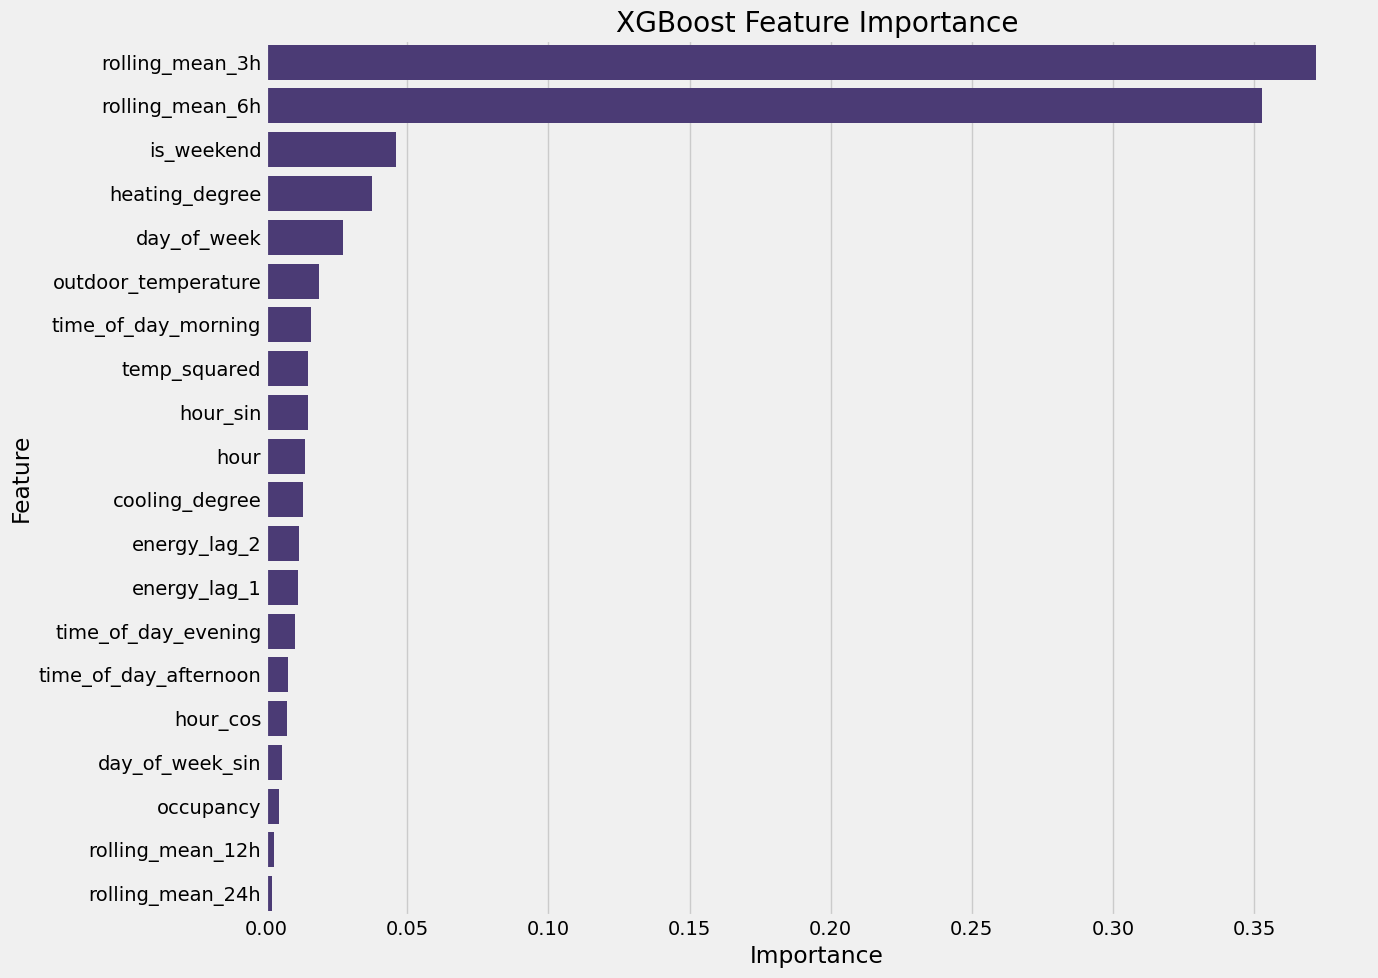

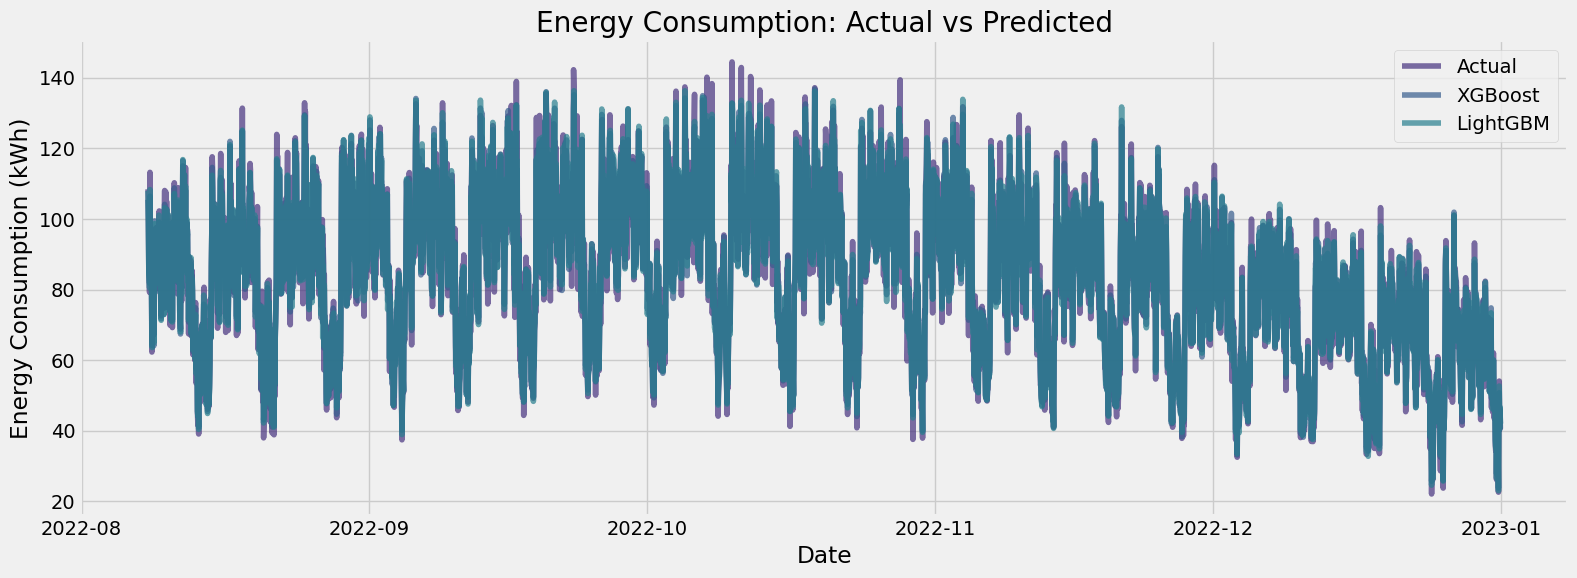

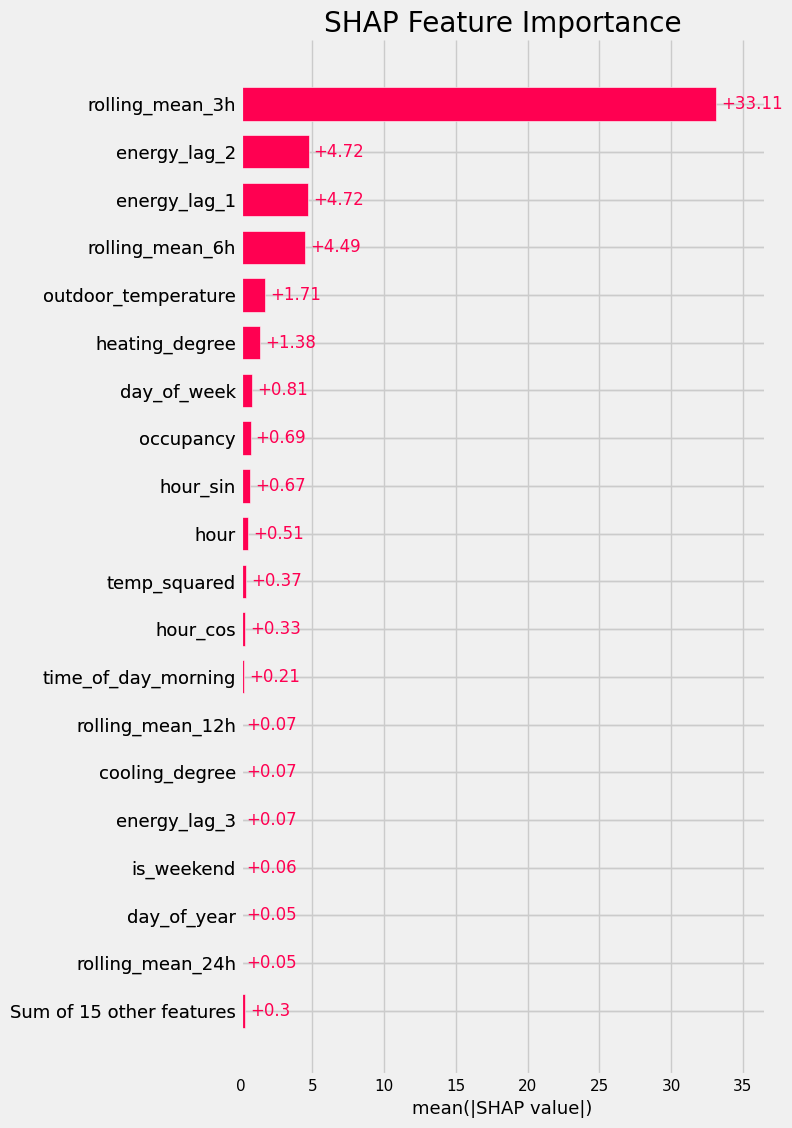

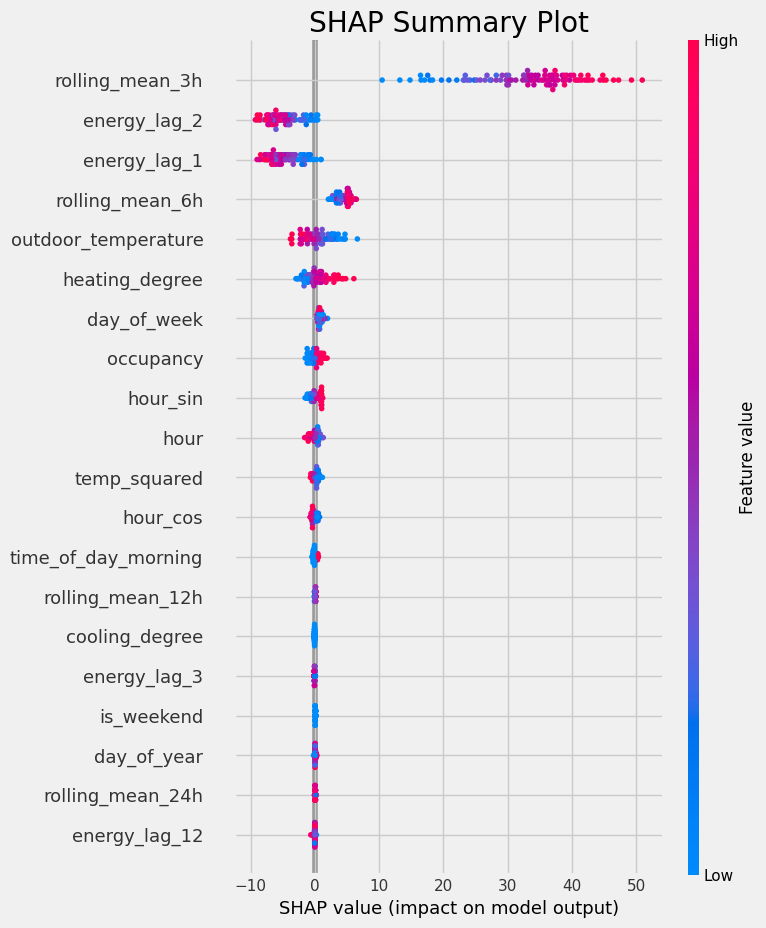

In [8]:
import shap

# --- Assumes these are defined earlier in your notebook:
# df, train_end, X_train, X_test, y_train, y_test, xgb_model, xgb_pred, lgbm_pred

# --- Plot feature importance from XGBoost
plt.figure(figsize=(14, 10))
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 20 features
top_features = feature_importance.head(20)
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# --- Plot predictions vs actual values
plt.figure(figsize=(16, 6))
test_dates = df.index[train_end:]
plt.plot(test_dates, y_test, label='Actual', alpha=0.7)
plt.plot(test_dates, xgb_pred, label='XGBoost', alpha=0.7)
plt.plot(test_dates, lgbm_pred, label='LightGBM', alpha=0.7)
plt.title('Energy Consumption: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

# --- SHAP analysis for XGBoost model
# Use the same exact structure of features as in training
X_test_sample = X_test.iloc[:100].copy()  # Use same column order & dtype as training

# SHAP Explainer for XGBoost
explainer = shap.Explainer(xgb_model)  # Modern SHAP interface (recommended)
shap_values = explainer(X_test_sample)

# --- SHAP Feature Importance (Bar plot)
plt.figure(figsize=(12, 10))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

# --- SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values.values, X_test_sample, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

### 1.7 Forecasting Future Energy Consumption

In [9]:
# # Generate predictions for the next 7 days (assuming hourly data)
# last_date = df.index[-1]
# forecast_horizon = 7 * 24  # 7 days of hourly predictions

# # Create a dataframe with future dates for forecasting
# future_dates = pd.date_range(
#     start=last_date + pd.Timedelta(hours=1),
#     periods=forecast_horizon,
#     freq='H'
# )

# # For demonstration, we'll use a simplified approach
# # In a real scenario, you would need future weather forecasts
# # Here we'll use seasonal patterns from historical data

# # Create future features
# future_df = pd.DataFrame(index=future_dates)
# future_df['hour'] = future_df.index.hour
# future_df['day'] = future_df.index.day
# future_df['month'] = future_df.index.month
# future_df['day_of_week'] = future_df.index.dayofweek
# future_df['day_of_year'] = future_df.index.dayofyear
# future_df['week_of_year'] = future_df.index.isocalendar().week
# future_df['is_weekend'] = future_df['day_of_week'].isin([5, 6]).astype(int)
# future_df['is_holiday'] = future_df.index.map(lambda x: x in us_holidays).astype(int)

# # Time of day categories
# future_df['time_of_day'] = pd.cut(
#     future_df['hour'], 
#     bins=[0, 6, 12, 18, 24], 
#     labels=['night', 'morning', 'afternoon', 'evening'],
#     include_lowest=True
# )
# future_df = pd.get_dummies(future_df, columns=['time_of_day'])

# # Cyclical encoding
# future_df = encode_cyclical(future_df, 'hour', 24)
# future_df = encode_cyclical(future_df, 'day_of_week', 7)
# future_df = encode_cyclical(future_df, 'month', 12)

# # Weather features (here we use averages by hour from historical data)
# hourly_temp_avg = df.groupby('hour')['outdoor_temperature'].mean()
# future_df['outdoor_temperature'] = future_df['hour'].map(hourly_temp_avg)
# future_df['temp_squared'] = future_df['outdoor_temperature'] ** 2
# future_df['heating_degree'] = np.maximum(18.5 - future_df['outdoor_temperature'], 0)
# future_df['cooling_degree'] = np.maximum(future_df['outdoor_temperature'] - 21, 0)

# # For lag features and rolling means, use the last known values from test data
# for i in [1, 2, 3, 6, 12, 24]:
#     last_values = df['energy_consumption'].iloc[-i:].values
#     future_df[f'energy_lag_{i}'] = np.nan
#     future_df[f'energy_lag_{i}'].iloc[0] = last_values[-1]

# # Initial rolling mean values
# for window in [3, 6, 12, 24]:
#     future_df[f'rolling_mean_{window}h'] = df['energy_consumption'].iloc[-window:].mean()

# # Generate predictions one by one to properly update lag features
# predictions = []
# best_model = lgbm_model  # Use the best performing model

# for i in range(forecast_horizon):
#     # Get the next row to predict
#     next_row = future_df.iloc[[i]]
    
#     # Make prediction
#     pred = best_model.predict(next_row)[0]
#     predictions.append(pred)
    
#     # Update lag features for future rows
#     if i + 1 < forecast_horizon:
#         for lag in [1, 2, 3, 6, 12, 24]:
#             if i + 1 >= lag:
#                 future_df[f'energy_lag_{lag}'].iloc[i + 1] = predictions[i - lag + 1]
#             else:
#                 if i + 1 - lag < 0:
#                     # Use historical data
#                     future_df[f'energy_lag_{lag}'].iloc[i + 1] = df['energy_consumption'].iloc[-lag + i + 1]
#                 else:
#                     # Use predicted data
#                     future_df[f'energy_lag_{lag}'].iloc[i + 1] = predictions[i + 1 - lag]
        
#         # Update rolling means
#         for window in [3, 6, 12, 24]:
#             if i + 1 >= window:
#                 future_df[f'rolling_mean_{window}h'].iloc[i + 1] = np.mean(predictions[i-window+1:i+1])
#             else:
#                 # Use a mix of historical and predicted
#                 hist_size = window - (i + 1)
#                 hist_values = df['energy_consumption'].iloc[-hist_size:].values
#                 pred_values = np.array(predictions[:i+1])
#                 combined = np.concatenate([hist_values, pred_values])
#                 future_df[f'rolling_mean_{window}h'].iloc[i + 1] = combined.mean()

# # Plot the forecast
# plt.figure(figsize=(16, 6))

# # Historical data (last 2 weeks)
# hist_dates = df.index[-14*24:]
# hist_values = df['energy_consumption'].iloc[-14*24:]
# plt.plot(hist_dates, hist_values, label='Historical', color='blue', alpha=0.7)

# # Forecast
# plt.plot(future_dates, predictions, label='Forecast', color='red', alpha=0.7)

# # Add vertical line separating historical from forecast
# plt.axvline(x=last_date, color='black', linestyle='--', alpha=0.7)
# plt.title('Energy Consumption Forecast')
# plt.xlabel('Date')
# plt.ylabel('Energy Consumption (kWh)')
# plt.legend()
# plt.tight_layout()
# plt.show()

```
LightGBMError: The number of features in data (32) is not the same as it was in training data (34).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.
```

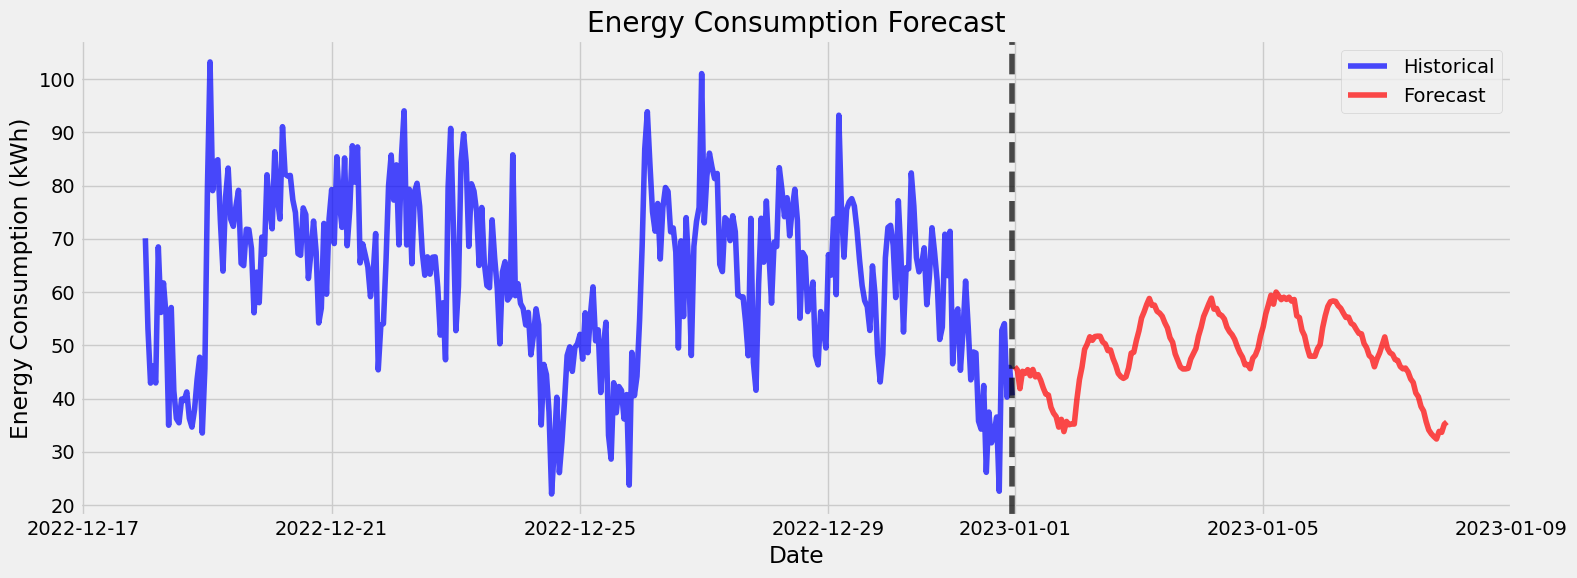

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume you already have:
# - trained LightGBM model: lgbm_model
# - original dataframe: df
# - U.S. holidays list: us_holidays
# - encode_cyclical function defined

# Set best_model if not defined
best_model = lgbm_model  # Ensure best_model is defined

# Save feature names from training (after model is trained)
training_features = best_model.booster_.feature_name()

# --- Create future dataframe ---
last_date = df.index[-1]
forecast_horizon = 7 * 24  # 7 days of hourly predictions

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(hours=1),
    periods=forecast_horizon,
    freq='H'
)

future_df = pd.DataFrame(index=future_dates)
future_df['hour'] = future_df.index.hour
future_df['day'] = future_df.index.day
future_df['month'] = future_df.index.month
future_df['day_of_week'] = future_df.index.dayofweek
future_df['day_of_year'] = future_df.index.dayofyear
future_df['week_of_year'] = future_df.index.isocalendar().week
future_df['is_weekend'] = future_df['day_of_week'].isin([5, 6]).astype(int)
future_df['is_holiday'] = future_df.index.map(lambda x: x in us_holidays).astype(int)

# Time of day categories
future_df['time_of_day'] = pd.cut(
    future_df['hour'], 
    bins=[0, 6, 12, 18, 24], 
    labels=['night', 'morning', 'afternoon', 'evening'],
    include_lowest=True
)
future_df = pd.get_dummies(future_df, columns=['time_of_day'])

# Cyclical encoding
future_df = encode_cyclical(future_df, 'hour', 24)
future_df = encode_cyclical(future_df, 'day_of_week', 7)
future_df = encode_cyclical(future_df, 'month', 12)

# Weather features using historical hourly averages
hourly_temp_avg = df.groupby('hour')['outdoor_temperature'].mean()
future_df['outdoor_temperature'] = future_df['hour'].map(hourly_temp_avg)
future_df['temp_squared'] = future_df['outdoor_temperature'] ** 2
future_df['heating_degree'] = np.maximum(18.5 - future_df['outdoor_temperature'], 0)
future_df['cooling_degree'] = np.maximum(future_df['outdoor_temperature'] - 21, 0)

# Lag features (initial values only for first row)
for i in [1, 2, 3, 6, 12, 24]:
    last_values = df['energy_consumption'].iloc[-i:].values
    future_df[f'energy_lag_{i}'] = np.nan
    future_df.at[future_df.index[0], f'energy_lag_{i}'] = last_values[-1]

# Rolling mean initial values
for window in [3, 6, 12, 24]:
    future_df[f'rolling_mean_{window}h'] = df['energy_consumption'].iloc[-window:].mean()

# Align features: match training features
for col in training_features:
    if col not in future_df.columns:
        future_df[col] = 0.0  # Add missing features
future_df = future_df[training_features]  # Reorder columns

# --- Generate predictions ---
predictions = []

for i in range(forecast_horizon):
    next_row = future_df.iloc[[i]]
    pred = best_model.predict(next_row)[0]
    predictions.append(pred)
    
    if i + 1 < forecast_horizon:
        # Update lag features
        for lag in [1, 2, 3, 6, 12, 24]:
            if i + 1 >= lag:
                future_df.at[future_df.index[i + 1], f'energy_lag_{lag}'] = predictions[i - lag + 1]
            else:
                hist_idx = -lag + i + 1
                if hist_idx < 0:
                    future_df.at[future_df.index[i + 1], f'energy_lag_{lag}'] = df['energy_consumption'].iloc[hist_idx]
                else:
                    future_df.at[future_df.index[i + 1], f'energy_lag_{lag}'] = predictions[hist_idx]
        
        # Update rolling means
        for window in [3, 6, 12, 24]:
            if i + 1 >= window:
                future_df.at[future_df.index[i + 1], f'rolling_mean_{window}h'] = np.mean(predictions[i - window + 2:i + 2])
            else:
                hist_size = window - (i + 1)
                hist_values = df['energy_consumption'].iloc[-hist_size:].values
                pred_values = np.array(predictions[:i + 1])
                combined = np.concatenate([hist_values, pred_values])
                future_df.at[future_df.index[i + 1], f'rolling_mean_{window}h'] = combined.mean()

# --- Plot results ---
plt.figure(figsize=(16, 6))
plt.plot(df.index[-14*24:], df['energy_consumption'].iloc[-14*24:], label='Historical', color='blue', alpha=0.7)
plt.plot(future_df.index, predictions, label='Forecast', color='red', alpha=0.7)
plt.axvline(x=last_date, color='black', linestyle='--', alpha=0.7)
plt.title('Energy Consumption Forecast')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

### 1.8 Cost Savings Analysis

In [11]:
# # Define electricity rates (example: time-of-use pricing)
# peak_rate = 0.28  # $/kWh during peak hours (12pm-8pm weekdays)
# off_peak_rate = 0.15  # $/kWh during off-peak hours

# # Function to calculate electricity cost
# def calculate_cost(consumption, dates):
#     peak_mask = ((dates.hour >= 12) & (dates.hour < 20) & (dates.dayofweek < 5))
#     peak_consumption = sum(consumption[peak_mask])
#     off_peak_consumption = sum(consumption[~peak_mask])
    
#     peak_cost = peak_consumption * peak_rate
#     off_peak_cost = off_peak_consumption * off_peak_rate
#     total_cost = peak_cost + off_peak_cost
    
#     return {
#         'peak_consumption': peak_consumption,
#         'off_peak_consumption': off_peak_consumption,
#         'peak_cost': peak_cost,
#         'off_peak_cost': off_peak_cost,
#         'total_cost': total_cost
#     }

# # Calculate costs for historical data and forecast
# historical_cost = calculate_cost(hist_values.values, hist_dates)
# forecast_cost = calculate_cost(np.array(predictions), future_dates)

# print("Historical Period (2 weeks):")
# print(f"Peak Consumption: {historical_cost['peak_consumption']:.2f} kWh")
# print(f"Off-Peak Consumption: {historical_cost['off_peak_consumption']:.2f} kWh")
# print(f"Peak Cost: ${historical_cost['peak_cost']:.2f}")
# print(f"Off-Peak Cost: ${historical_cost['off_peak_cost']:.2f}")
# print(f"Total Cost: ${historical_cost['total_cost']:.2f}")

# print("\nForecast Period (1 week):")
# print(f"Peak Consumption: {forecast_cost['peak_consumption']:.2f} kWh")
# print(f"Off-Peak Consumption: {forecast_cost['off_peak_consumption']:.2f} kWh")
# print(f"Peak Cost: ${forecast_cost['peak_cost']:.2f}")
# print(f"Off-Peak Cost: ${forecast_cost['off_peak_cost']:.2f}")
# print(f"Total Cost: ${forecast_cost['total_cost']:.2f}")

# # Cost reduction scenario (e.g., shifting 10% of peak load to off-peak)
# shift_percent = 0.1
# shifted_forecast_cost = calculate_cost(np.array(predictions), future_dates)
# shifted_peak = forecast_cost['peak_consumption'] * (1 - shift_percent)
# shifted_off_peak = forecast_cost['off_peak_consumption'] + (forecast_cost['peak_consumption'] * shift_percent)

# shifted_cost = {
#     'peak_consumption': shifted_peak,
#     'off_peak_consumption': shifted_off_peak,
#     'peak_cost': shifted_peak * peak_rate,
#     'off_peak_cost': shifted_off_peak * off_peak_rate,
#     'total_cost': (shifted_peak * peak_rate) + (shifted_off_peak * off_peak_rate)
# }

# print("\nForecast with Load Shifting (10% from peak to off-peak):")
# print(f"Peak Consumption: {shifted_cost['peak_consumption']:.2f} kWh")
# print(f"Off-Peak Consumption: {shifted_cost['off_peak_consumption']:.2f} kWh")
# print(f"Peak Cost: ${shifted_cost['peak_cost']:.2f}")
# print(f"Off-Peak Cost: ${shifted_cost['off_peak_cost']:.2f}")
# print(f"Total Cost: ${shifted_cost['total_cost']:.2f}")
# print(f"Savings: ${forecast_cost['total_cost'] - shifted_cost['total_cost']:.2f}")

```
AttributeError: 'numpy.ndarray' object has no attribute 'values'
```

In [12]:
# Define electricity rates (example: time-of-use pricing)
peak_rate = 0.28  # $/kWh during peak hours (12pm-8pm weekdays)
off_peak_rate = 0.15  # $/kWh during off-peak hours

# Function to calculate electricity cost
def calculate_cost(consumption, dates):
    peak_mask = ((dates.hour >= 12) & (dates.hour < 20) & (dates.dayofweek < 5))
    peak_consumption = sum(consumption[peak_mask])
    off_peak_consumption = sum(consumption[~peak_mask])
    
    peak_cost = peak_consumption * peak_rate
    off_peak_cost = off_peak_consumption * off_peak_rate
    total_cost = peak_cost + off_peak_cost
    
    return {
        'peak_consumption': peak_consumption,
        'off_peak_consumption': off_peak_consumption,
        'peak_cost': peak_cost,
        'off_peak_cost': off_peak_cost,
        'total_cost': total_cost
    }

# Prepare historical data (last 2 weeks)
hist_values = df['energy_consumption'].iloc[-14*24:].to_numpy()  # or .values
hist_dates = df.index[-14*24:]

# Calculate costs for historical data and forecast
historical_cost = calculate_cost(hist_values, hist_dates)
forecast_cost = calculate_cost(np.array(predictions), future_dates)

print("Historical Period (2 weeks):")
print(f"Peak Consumption: {historical_cost['peak_consumption']:.2f} kWh")
print(f"Off-Peak Consumption: {historical_cost['off_peak_consumption']:.2f} kWh")
print(f"Peak Cost: ${historical_cost['peak_cost']:.2f}")
print(f"Off-Peak Cost: ${historical_cost['off_peak_cost']:.2f}")
print(f"Total Cost: ${historical_cost['total_cost']:.2f}")

print("\nForecast Period (1 week):")
print(f"Peak Consumption: {forecast_cost['peak_consumption']:.2f} kWh")
print(f"Off-Peak Consumption: {forecast_cost['off_peak_consumption']:.2f} kWh")
print(f"Peak Cost: ${forecast_cost['peak_cost']:.2f}")
print(f"Off-Peak Cost: ${forecast_cost['off_peak_cost']:.2f}")
print(f"Total Cost: ${forecast_cost['total_cost']:.2f}")

# Cost reduction scenario (e.g., shifting 10% of peak load to off-peak)
shift_percent = 0.1
shifted_peak = forecast_cost['peak_consumption'] * (1 - shift_percent)
shifted_off_peak = forecast_cost['off_peak_consumption'] + (forecast_cost['peak_consumption'] * shift_percent)

shifted_cost = {
    'peak_consumption': shifted_peak,
    'off_peak_consumption': shifted_off_peak,
    'peak_cost': shifted_peak * peak_rate,
    'off_peak_cost': shifted_off_peak * off_peak_rate,
    'total_cost': (shifted_peak * peak_rate) + (shifted_off_peak * off_peak_rate)
}

print("\nForecast with Load Shifting (10% from peak to off-peak):")
print(f"Peak Consumption: {shifted_cost['peak_consumption']:.2f} kWh")
print(f"Off-Peak Consumption: {shifted_cost['off_peak_consumption']:.2f} kWh")
print(f"Peak Cost: ${shifted_cost['peak_cost']:.2f}")
print(f"Off-Peak Cost: ${shifted_cost['off_peak_cost']:.2f}")
print(f"Total Cost: ${shifted_cost['total_cost']:.2f}")
print(f"Savings: ${forecast_cost['total_cost'] - shifted_cost['total_cost']:.2f}")

Historical Period (2 weeks):
Peak Consumption: 5012.36 kWh
Off-Peak Consumption: 16010.62 kWh
Peak Cost: $1403.46
Off-Peak Cost: $2401.59
Total Cost: $3805.06

Forecast Period (1 week):
Peak Consumption: 1955.65 kWh
Off-Peak Consumption: 6233.94 kWh
Peak Cost: $547.58
Off-Peak Cost: $935.09
Total Cost: $1482.67

Forecast with Load Shifting (10% from peak to off-peak):
Peak Consumption: 1760.09 kWh
Off-Peak Consumption: 6429.50 kWh
Peak Cost: $492.82
Off-Peak Cost: $964.43
Total Cost: $1457.25
Savings: $25.42


## 2. Classification: Credit Risk Assessment

### 2.1 Problem Statement and Business Context

Accurate credit risk assessment is crucial for financial institutions to make informed lending decisions. In this case study, we'll develop a classification model to predict the likelihood of loan default, helping lenders optimize their risk management strategies.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('fivethirtyeight')
sns.set_palette('viridis')

### 2.2 Dataset Description and Loading

We'll use a comprehensive credit risk dataset that includes loan data, borrower information, and historical payment patterns.

In [14]:
# Load the dataset
credit_data = pd.read_csv('credit_risk_data.csv')

# Display basic information
print(f"Dataset shape: {credit_data.shape}")
print(f"Missing values: {credit_data.isnull().sum().sum()}")

# Check for target class imbalance
print("\nTarget class distribution:")
print(credit_data['loan_default'].value_counts())
print(credit_data['loan_default'].value_counts(normalize=True).map("{:.2%}".format))

# Preview the data
print("\nData preview:")
print(credit_data.head())

# Summary statistics
print("\nSummary statistics:")
print(credit_data.describe())

# Column types
print("\nColumn data types:")
print(credit_data.dtypes)

Dataset shape: (10000, 17)
Missing values: 0

Target class distribution:
loan_default
0    8465
1    1535
Name: count, dtype: int64
loan_default
0    84.65%
1    15.35%
Name: proportion, dtype: object

Data preview:
  Customer ID  loan_default   loan_amount  annual_income   age  \
0  CUST-00000             0  23430.189415  116301.165754  45.0   
1  CUST-00001             0  24533.850886   92876.714947  49.0   
2  CUST-00002             0  32162.586016  154009.942350  49.0   
3  CUST-00003             0  27711.722187   74817.696802  50.0   
4  CUST-00004             0  24803.000930  138171.462423  48.0   

   employment_length  debt_to_income  credit_limit   credit_used  \
0               12.0        0.475836  31962.566391  21733.793191   
1               10.0        0.341414  24450.543625  17570.588636   
2               20.0        0.354333  28401.223552  21950.778491   
3               15.0        0.471411  15348.141710  10539.878566   
4               18.0        0.382820  35349.620

### 2.3 Exploratory Data Analysis

Let's understand the factors influencing loan defaults.

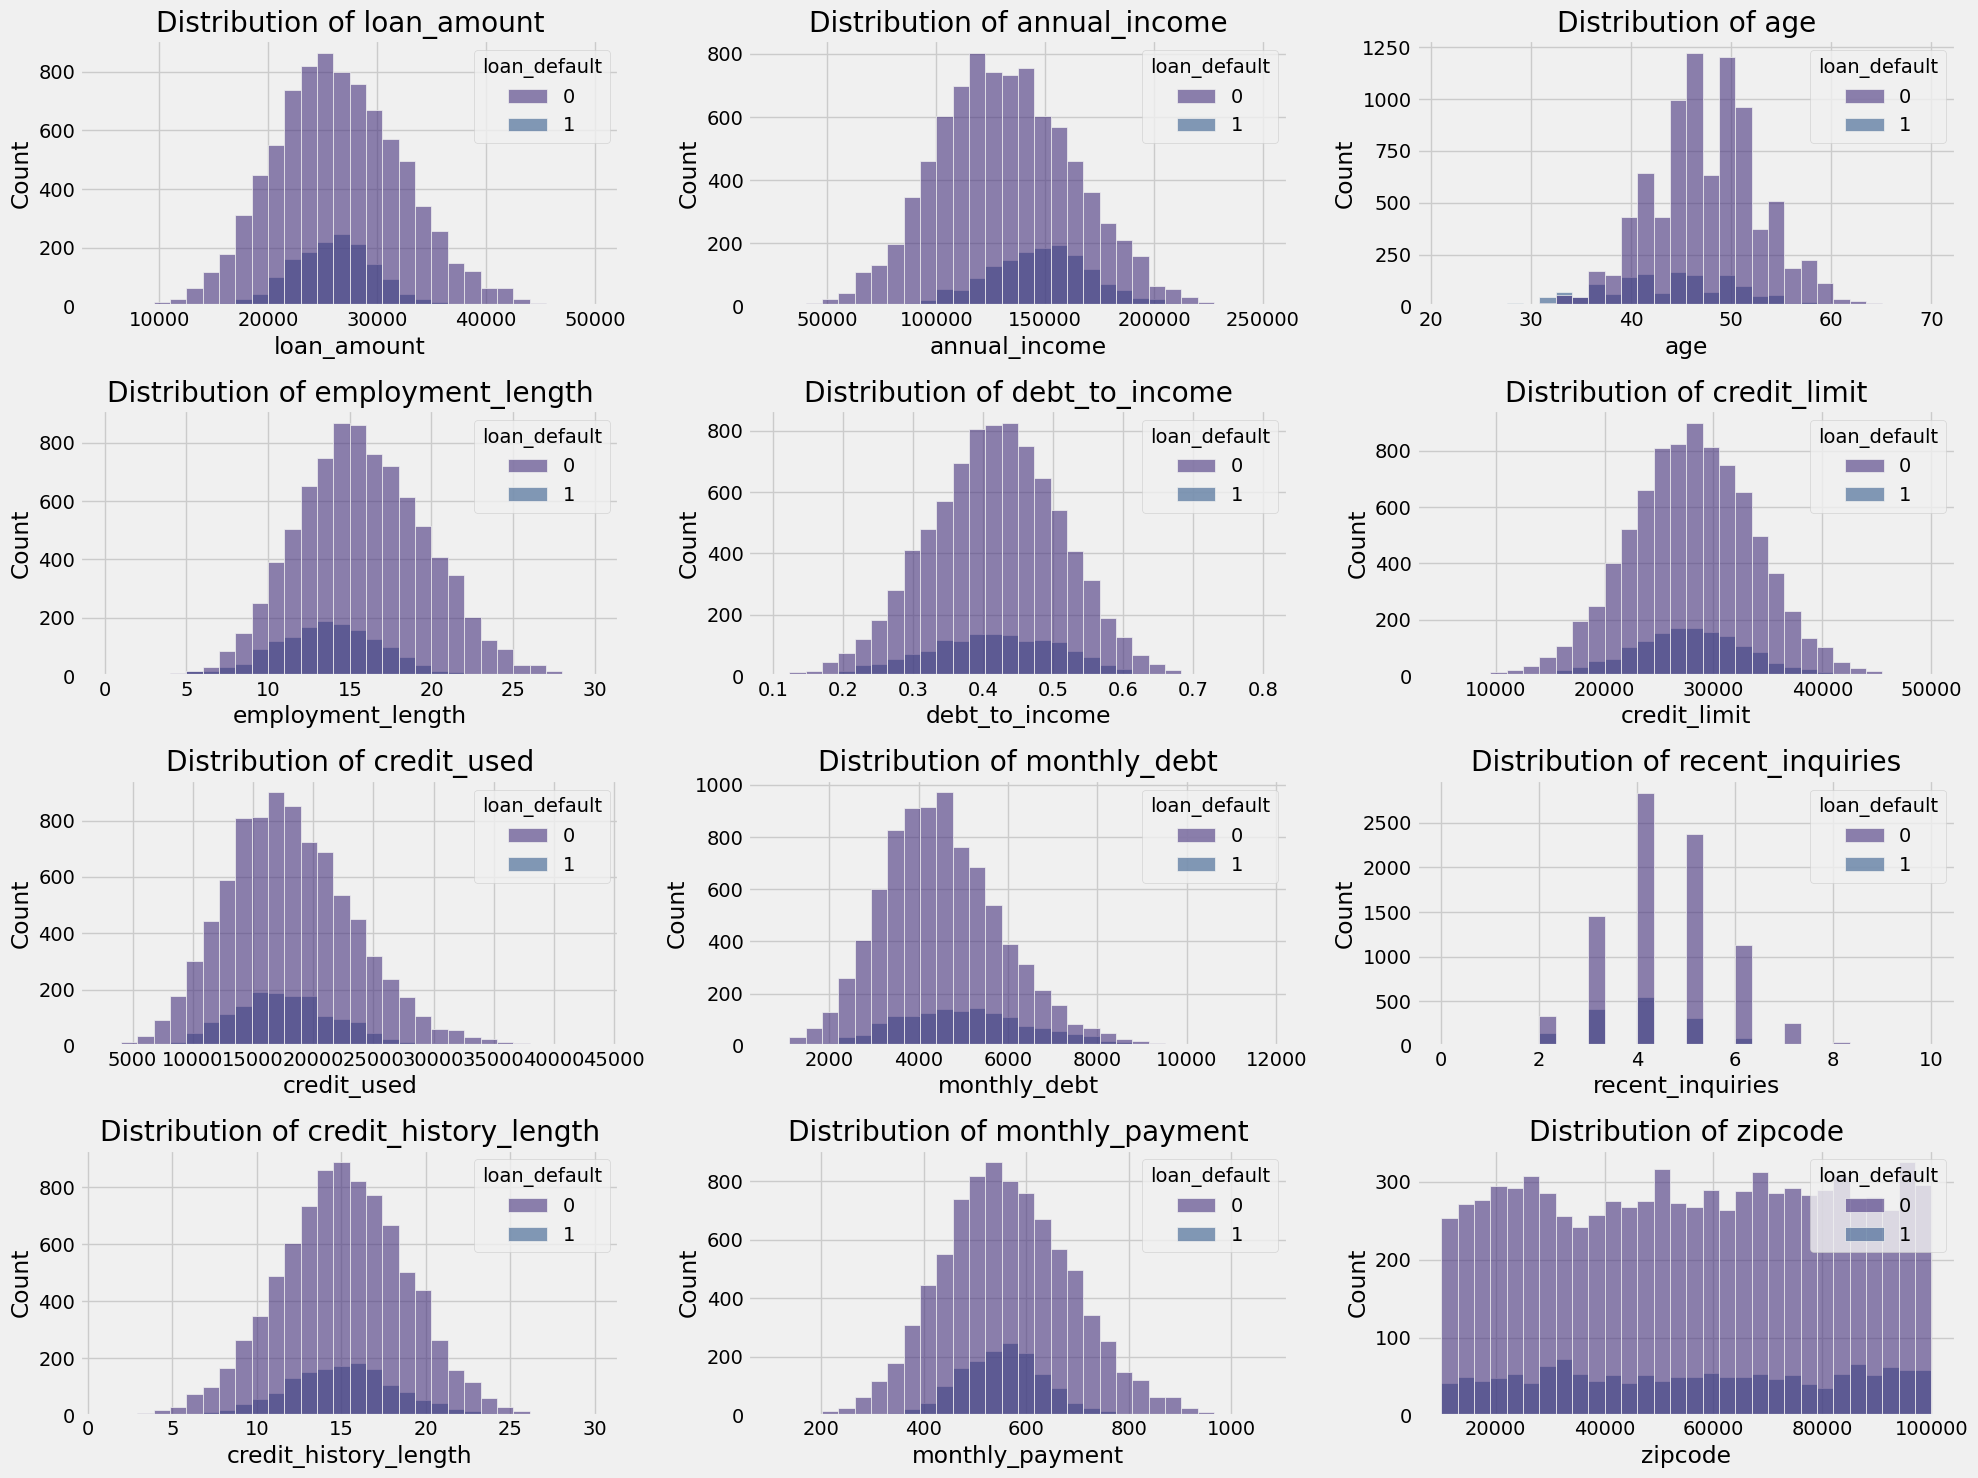

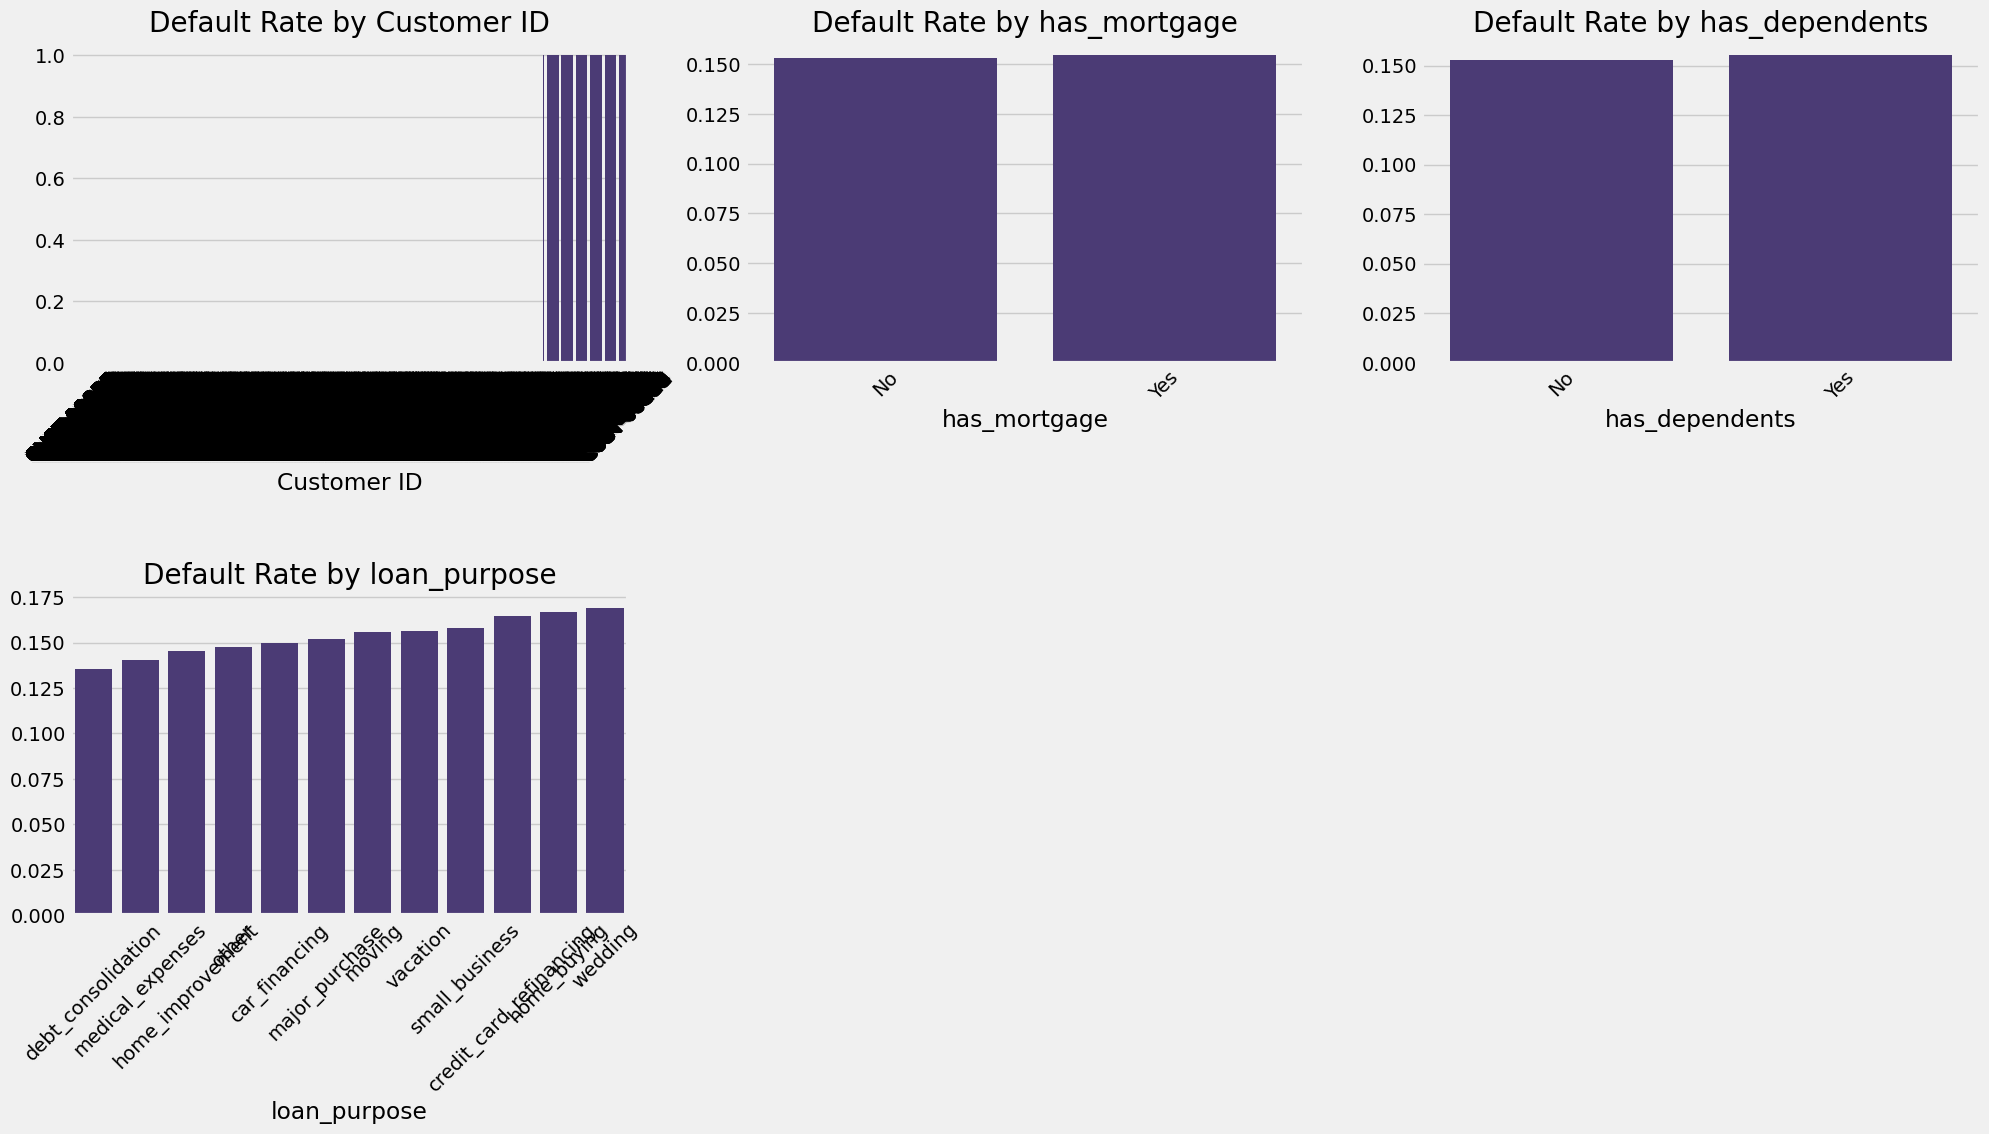

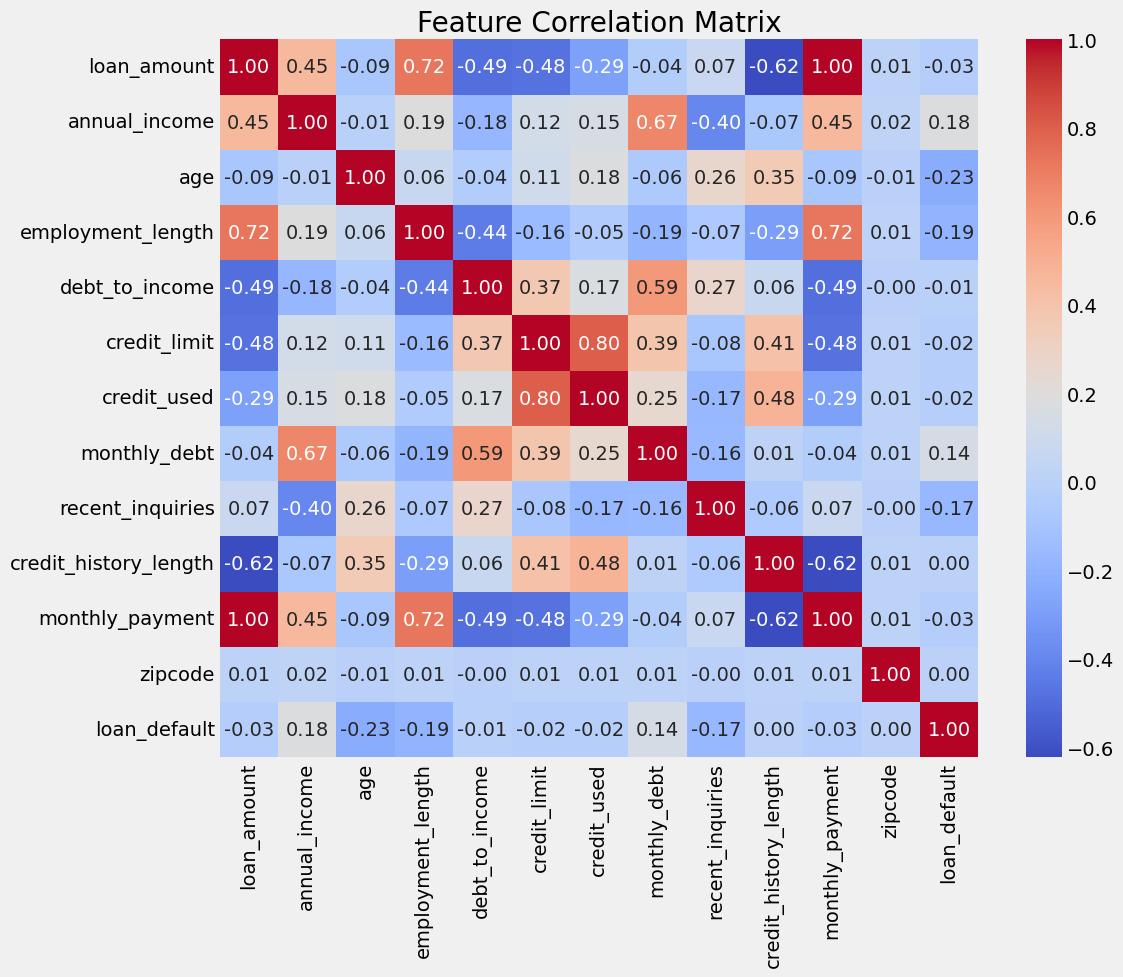

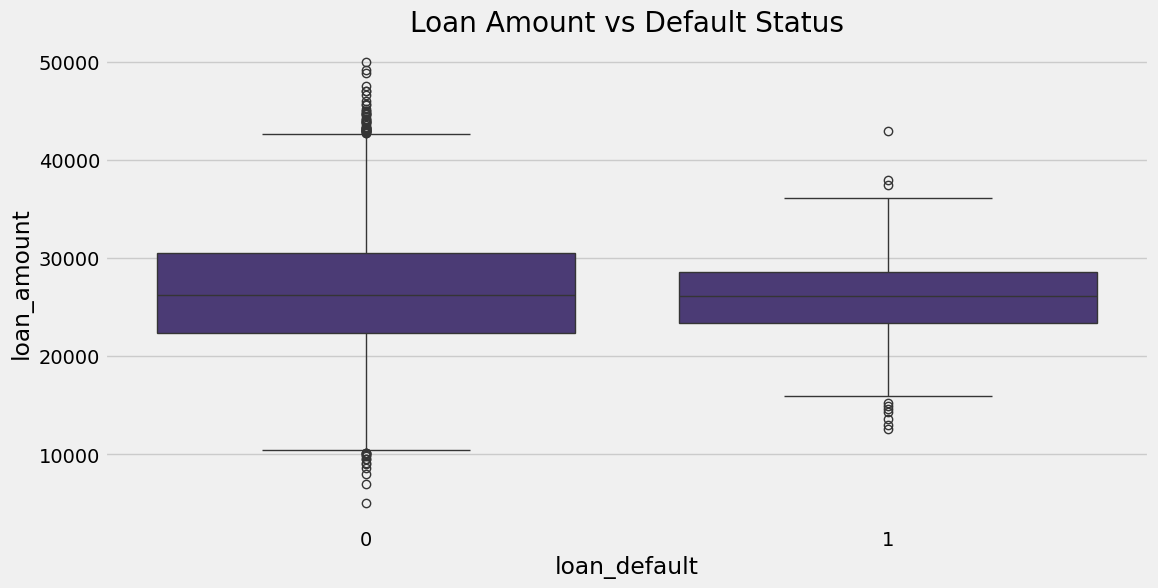

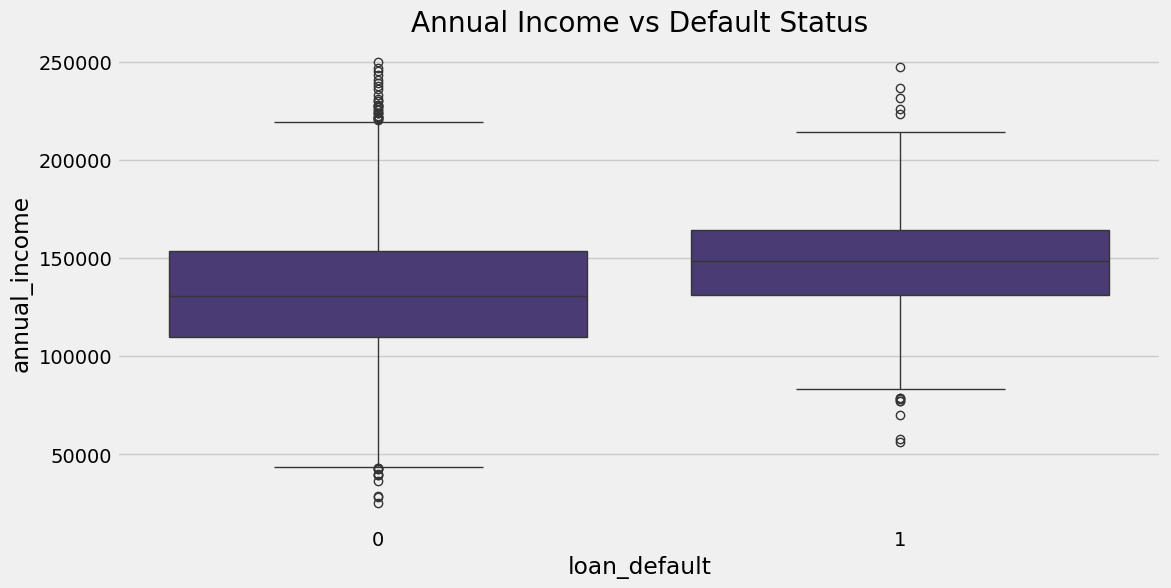

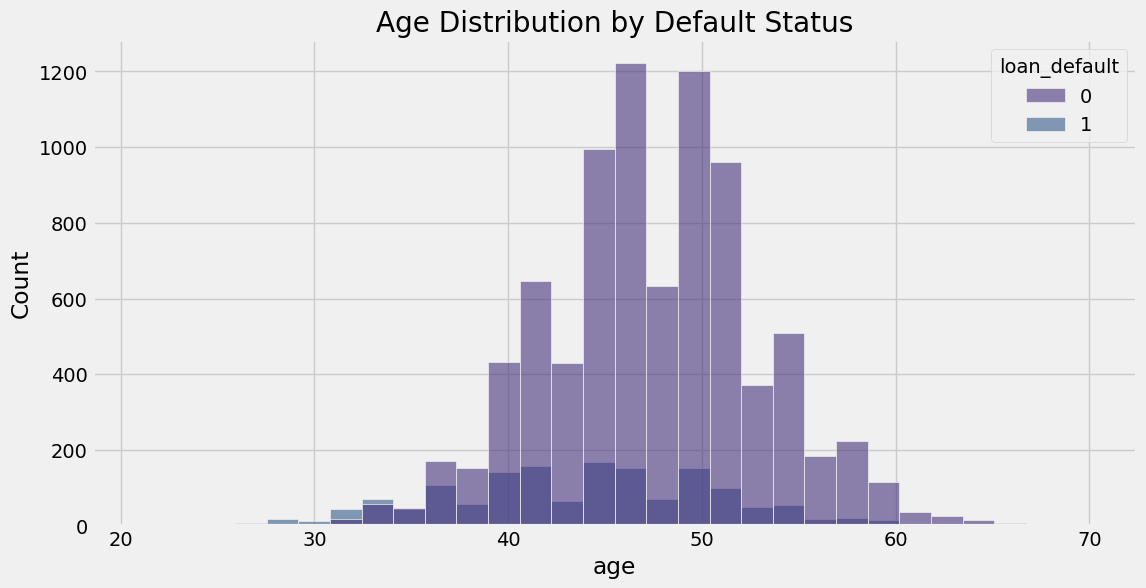

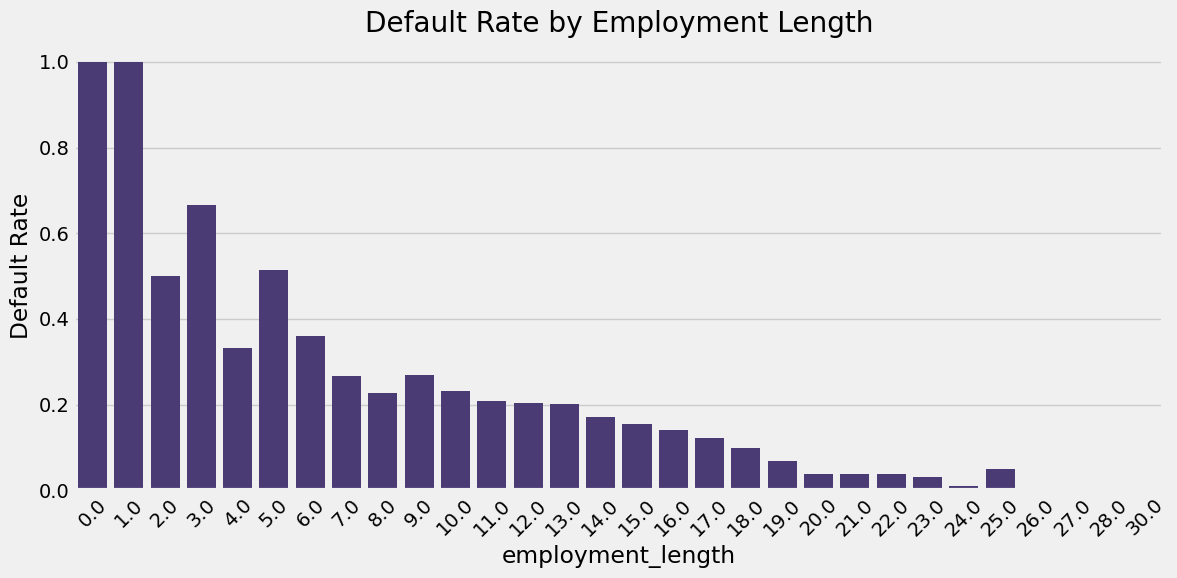

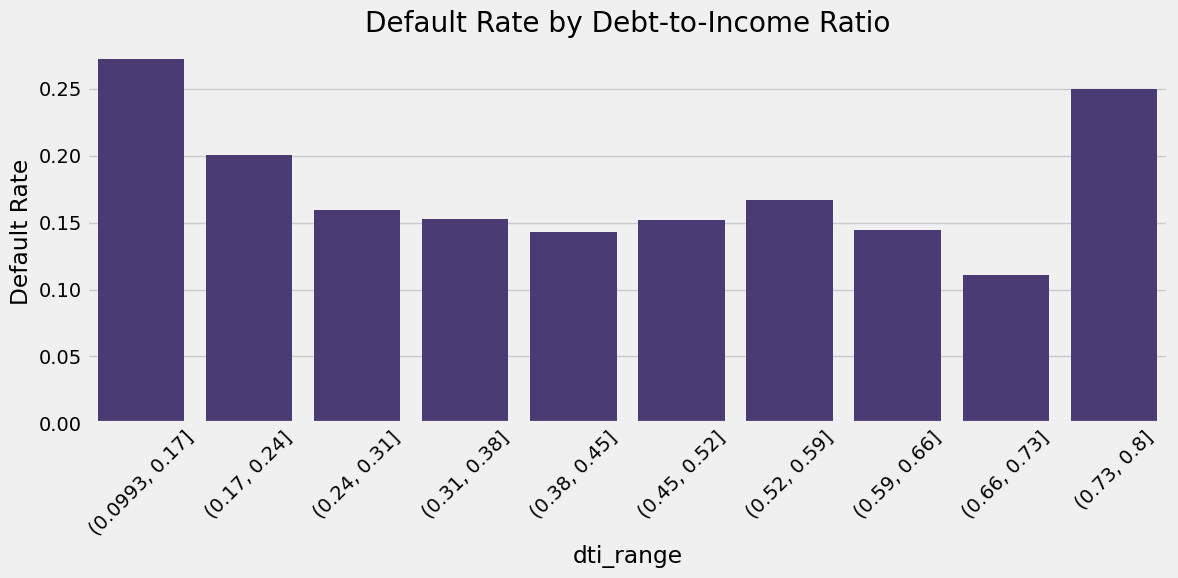

In [15]:
# Distribution of numeric features
numeric_features = credit_data.select_dtypes(include=['int64', 'float64']).columns
numeric_features = [col for col in numeric_features if col != 'loan_default']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features[:12]):  # First 12 features
    plt.subplot(4, 3, i+1)
    sns.histplot(data=credit_data, x=feature, hue='loan_default', bins=30, alpha=0.6)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()
plt.show()

# Categorical features analysis
categorical_features = credit_data.select_dtypes(include=['object']).columns

plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features[:9]):  # First 9 features
    plt.subplot(3, 3, i+1)
    default_rates = credit_data.groupby(feature)['loan_default'].mean().sort_values()
    sns.barplot(x=default_rates.index, y=default_rates.values)
    plt.title(f'Default Rate by {feature}')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

# Correlation matrix for numeric features
plt.figure(figsize=(12, 10))
correlation = credit_data[numeric_features + ['loan_default']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Default rate by loan amount
plt.figure(figsize=(12, 6))
sns.boxplot(x='loan_default', y='loan_amount', data=credit_data)
plt.title('Loan Amount vs Default Status')
plt.show()

# Default rate by income
plt.figure(figsize=(12, 6))
sns.boxplot(x='loan_default', y='annual_income', data=credit_data)
plt.title('Annual Income vs Default Status')
plt.show()

# Age distribution by default status
plt.figure(figsize=(12, 6))
sns.histplot(data=credit_data, x='age', hue='loan_default', bins=30, alpha=0.6)
plt.title('Age Distribution by Default Status')
plt.show()

# Default rate by employment length
plt.figure(figsize=(12, 6))
employment_default = credit_data.groupby('employment_length')['loan_default'].mean().sort_values()
sns.barplot(x=employment_default.index, y=employment_default.values)
plt.title('Default Rate by Employment Length')
plt.xticks(rotation=45)
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

# Default rate by debt-to-income ratio
plt.figure(figsize=(12, 6))
credit_data['dti_range'] = pd.cut(credit_data['debt_to_income'], bins=10)
dti_default = credit_data.groupby('dti_range')['loan_default'].mean()
sns.barplot(x=dti_default.index.astype(str), y=dti_default.values)
plt.title('Default Rate by Debt-to-Income Ratio')
plt.xticks(rotation=45)
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

### 2.4 Data Preprocessing and Feature Engineering

In [16]:
# Data cleaning and feature engineering
df = credit_data.copy()

# Convert binary categorical variables
binary_features = ['has_mortgage', 'has_dependents']
for col in binary_features:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Handle missing values for now (a better strategy would be determined during EDA)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
    
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Create new features
# Credit utilization ratio (credit_used / credit_limit)
df['credit_utilization'] = df['credit_used'] / df['credit_limit']
df['credit_utilization'].fillna(0, inplace=True)
df['credit_utilization'] = df['credit_utilization'].clip(0, 1)  # Cap at 100%

# Monthly debt-to-income ratio
df['monthly_dti'] = df['monthly_debt'] / (df['annual_income'] / 12)
df['monthly_dti'].fillna(0, inplace=True)
df['monthly_dti'] = df['monthly_dti'].clip(0, 1)  # Cap at 100%

# Loan amount to income ratio
df['loan_to_income'] = df['loan_amount'] / df['annual_income']
df['loan_to_income'].fillna(0, inplace=True)

# Number of credit inquiries to credit history ratio
df['inquiry_to_history_ratio'] = df['recent_inquiries'] / df['credit_history_length']
df['inquiry_to_history_ratio'].fillna(0, inplace=True)

# Payment to income ratio
df['payment_to_income'] = df['monthly_payment'] / (df['annual_income'] / 12)
df['payment_to_income'].fillna(0, inplace=True)

# Binning high-cardinality categorical variables
# df['zipcode_bin'] = df['zipcode'].str[:3]  # First 3 digits of ZIP code
df['zipcode_bin'] = df['zipcode'].astype(str).str[:3]  # First 3 digits of ZIP code
df['loan_purpose_category'] = df['loan_purpose'].replace({
    'home_improvement': 'home',
    'home_buying': 'home',
    'debt_consolidation': 'debt',
    'credit_card_refinancing': 'debt',
    'major_purchase': 'purchase',
    'small_business': 'business',
    'medical_expenses': 'personal',
    'vacation': 'personal',
    'moving': 'personal',
    'wedding': 'personal',
    'car_financing': 'purchase',
    'other': 'other'
})

# Prepare data for modeling
# X = df.drop(['loan_default', 'zipcode', 'customer_id'], axis=1)
X = df.drop(['loan_default', 'zipcode', 'Customer ID'], axis=1)
y = df['loan_default']

# Split the data into features and target variable
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Total features: {len(categorical_features) + len(numeric_features)}")

Categorical features: 3
Numeric features: 18
Total features: 21


```
AttributeError: Can only use .str accessor with string values!

UPDATE:
df['zipcode_bin'] = df['zipcode'].astype(str).str[:3]  # First 3 digits of ZIP code

KeyError: "['customer_id'] not found in axis"

UPDATE:
X = df.drop(['loan_default', 'zipcode', 'Customer ID'], axis=1)
```

### 2.5 Model Development

We'll implement multiple classification models and handle the class imbalance.

Training set size: (8000, 22)
Testing set size: (2000, 22)
Class distribution in training set: [6772 1228]
Class distribution in testing set: [1693  307]
Training Random Forest...
Random Forest CV ROC-AUC: 0.9315 ± 0.0133
Training XGBoost...
XGBoost CV ROC-AUC: 0.9624 ± 0.0089
Training LightGBM...
[LightGBM] [Info] Number of positive: 5417, number of negative: 5417
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11573
[LightGBM] [Info] Number of data points in the train set: 10834, number of used features: 350
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5417, number of negative: 5417
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014592 seconds.
You can set `force_row_wi

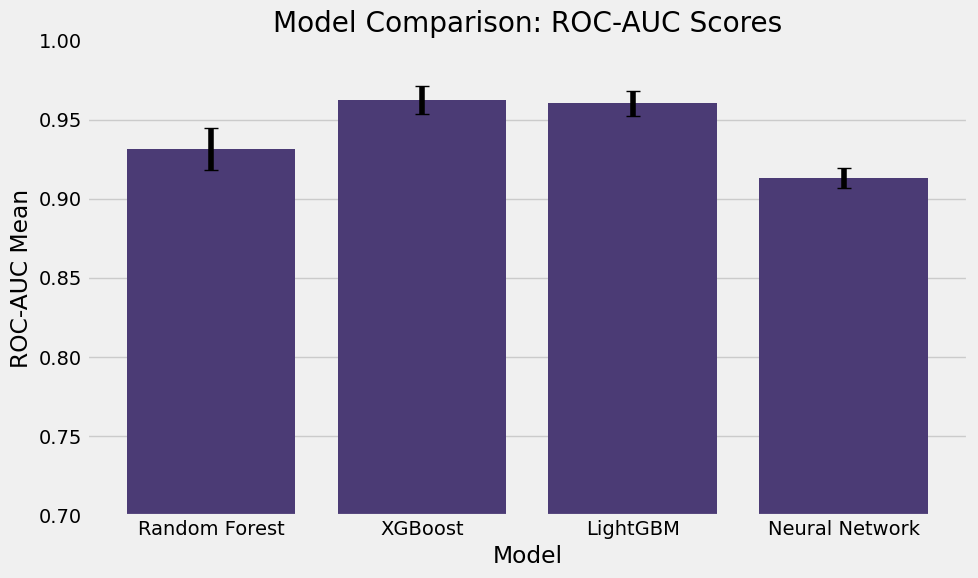

In [17]:
# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in testing set: {np.bincount(y_test)}")

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

# Create model pipelines with SMOTE
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

lgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', LGBMClassifier(random_state=42))
])

nn_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42))
])

# Train all models
models = {
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'LightGBM': lgb_pipeline,
    'Neural Network': nn_pipeline
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    print(f"Training {name}...")
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }
    print(f"{name} CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)

# Compare models with CV results
cv_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'ROC-AUC Mean': [cv_results[model]['mean'] for model in cv_results],
    'ROC-AUC Std': [cv_results[model]['std'] for model in cv_results]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC-AUC Mean', data=cv_df)
plt.errorbar(x=range(len(cv_df)), y=cv_df['ROC-AUC Mean'], 
             yerr=cv_df['ROC-AUC Std'], fmt='none', c='black', capsize=5)
plt.title('Model Comparison: ROC-AUC Scores')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

```
TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

UPDATE:
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
```

### 2.6 Model Evaluation and Comparison


Random Forest Test Results:
ROC-AUC: 0.9331
Average Precision: 0.7705
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1693
           1       0.78      0.59      0.67       307

    accuracy                           0.91      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.91      0.91      0.91      2000



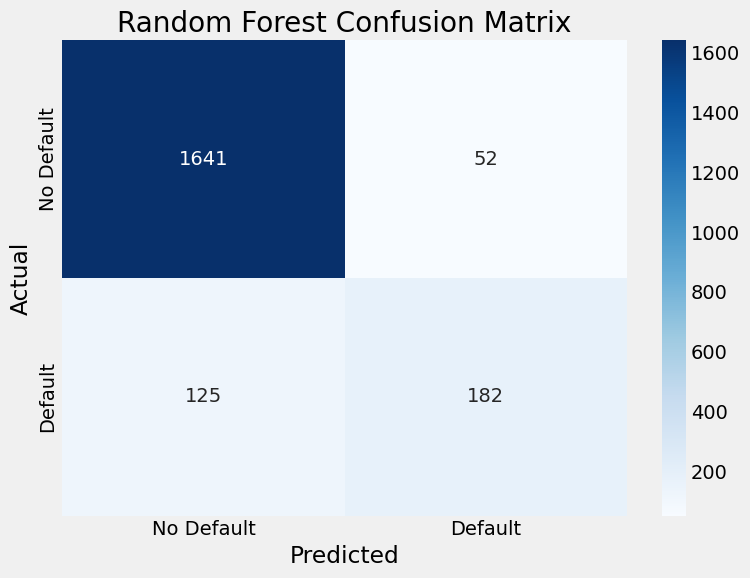


XGBoost Test Results:
ROC-AUC: 0.9664
Average Precision: 0.8841
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1693
           1       0.85      0.79      0.82       307

    accuracy                           0.95      2000
   macro avg       0.91      0.88      0.89      2000
weighted avg       0.94      0.95      0.95      2000



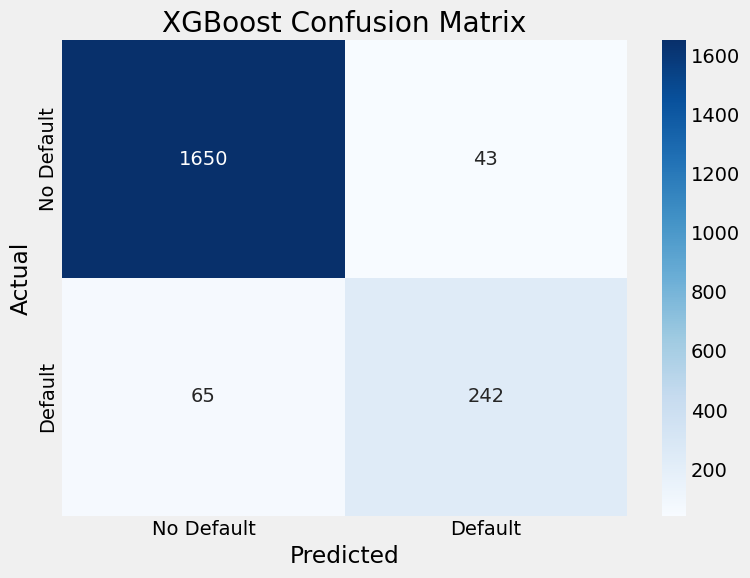


LightGBM Test Results:
ROC-AUC: 0.9690
Average Precision: 0.8947
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1693
           1       0.83      0.78      0.80       307

    accuracy                           0.94      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.94      0.94      0.94      2000



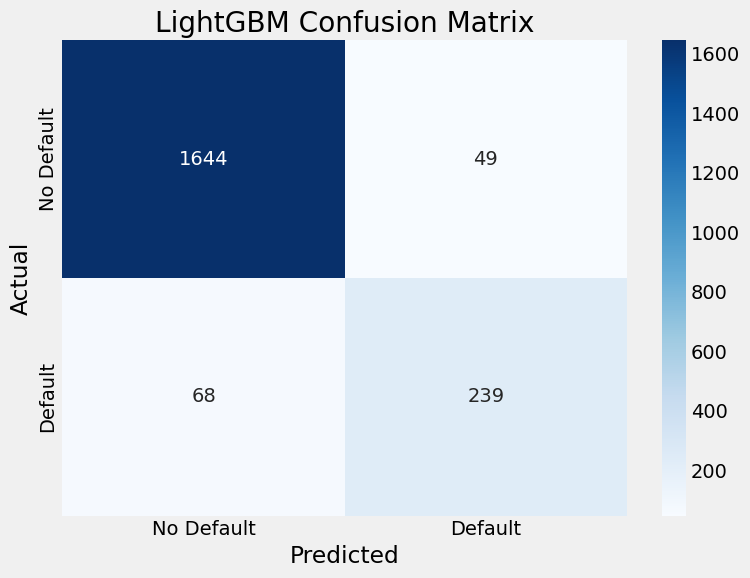


Neural Network Test Results:
ROC-AUC: 0.9058
Average Precision: 0.7572
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1693
           1       0.72      0.64      0.68       307

    accuracy                           0.91      2000
   macro avg       0.83      0.80      0.81      2000
weighted avg       0.90      0.91      0.90      2000



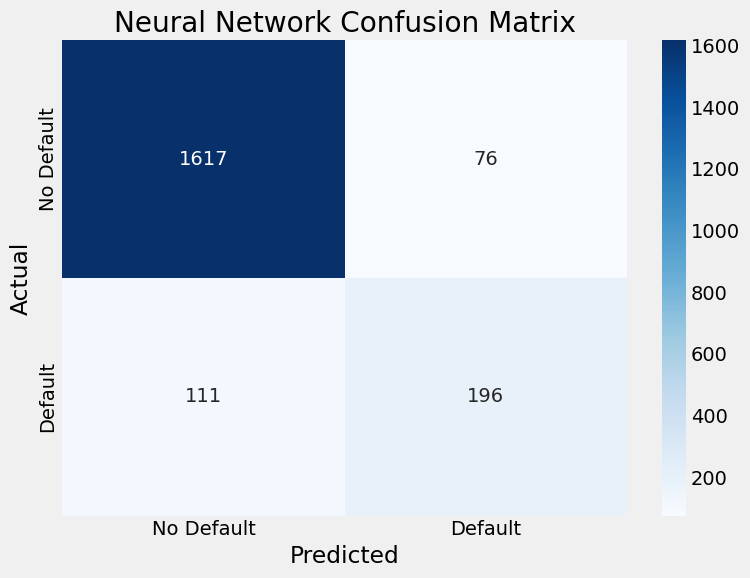

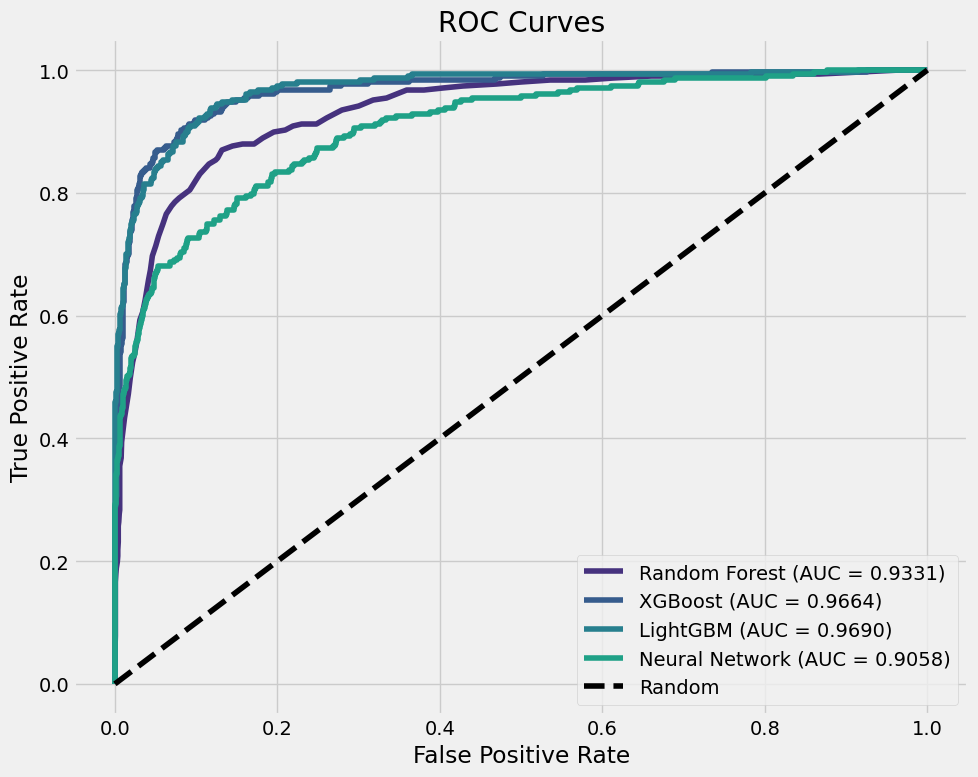

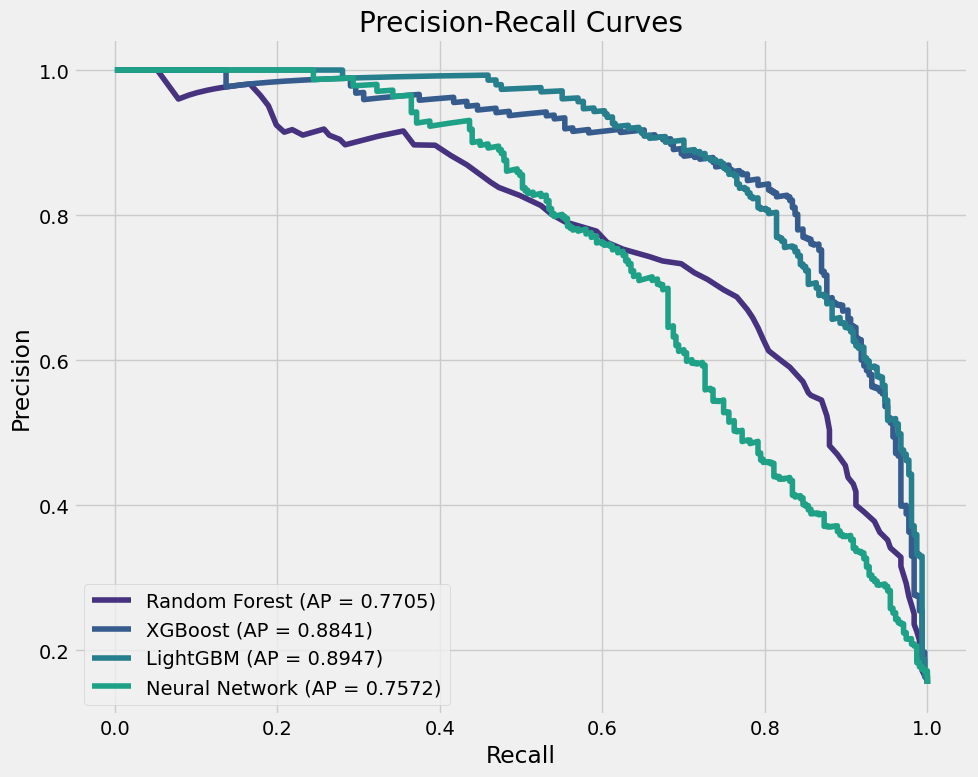

In [18]:
# Evaluate models on the test set
test_results = {}

for name, model in models.items():
    # Predict class probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Predict classes
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    
    test_results[name] = {
        'y_prob': y_prob,
        'y_pred': y_pred,
        'auc': auc,
        'avg_precision': avg_precision
    }
    
    print(f"\n{name} Test Results:")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Default', 'Default'], 
                yticklabels=['No Default', 'Default'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, results in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['y_prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))

for name, results in test_results.items():
    precision, recall, _ = precision_recall_curve(y_test, results['y_prob'])
    plt.plot(recall, precision, label=f'{name} (AP = {results["avg_precision"]:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.tight_layout()
plt.show()

### 2.7 Feature Importance and Model Interpretation

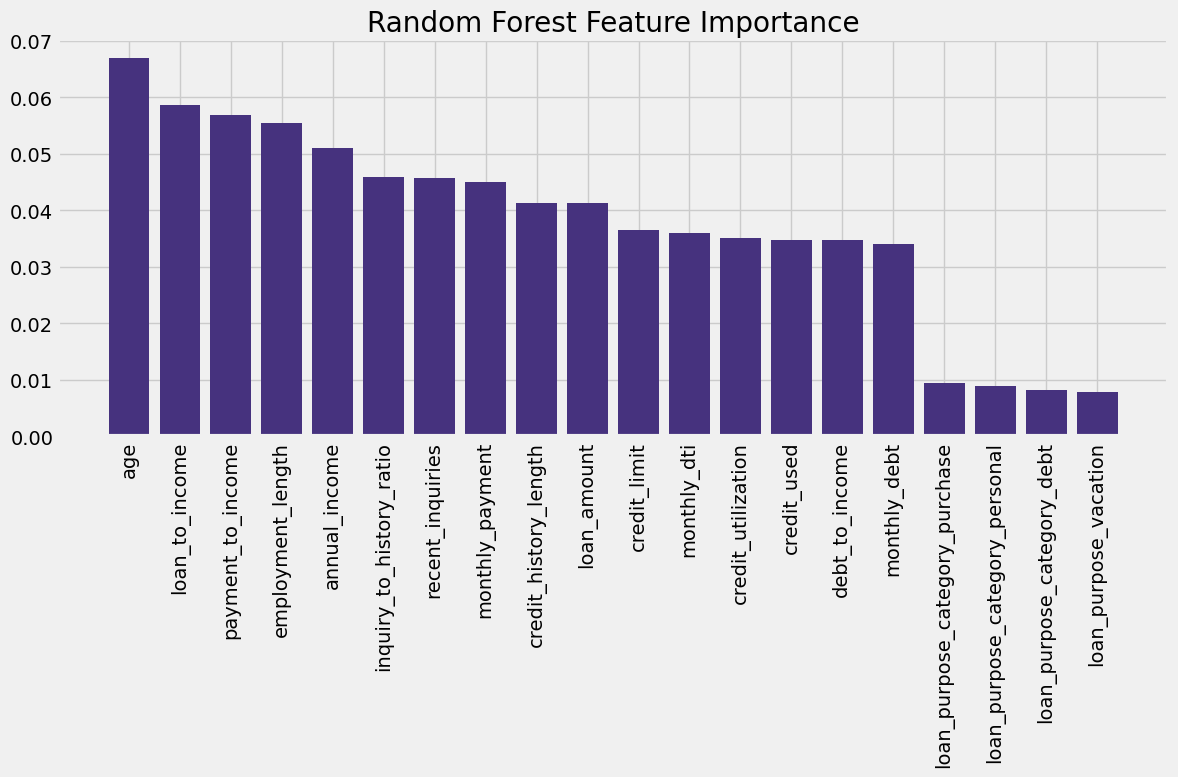

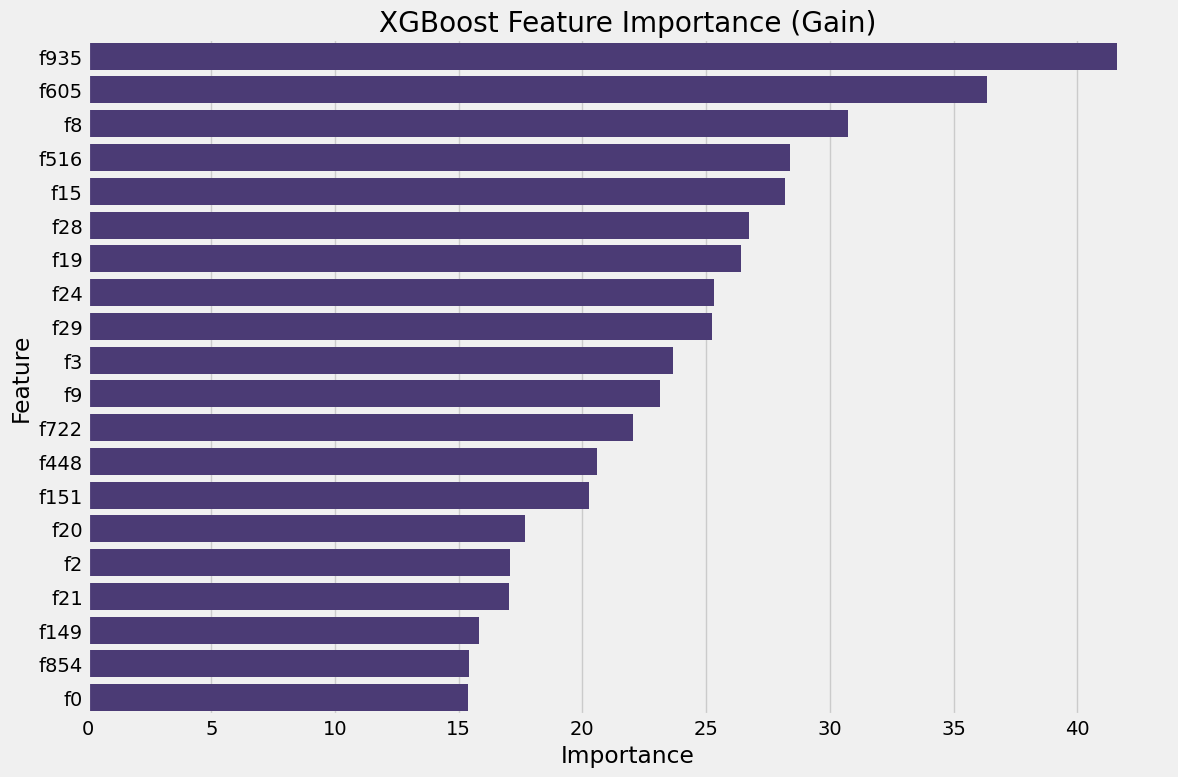

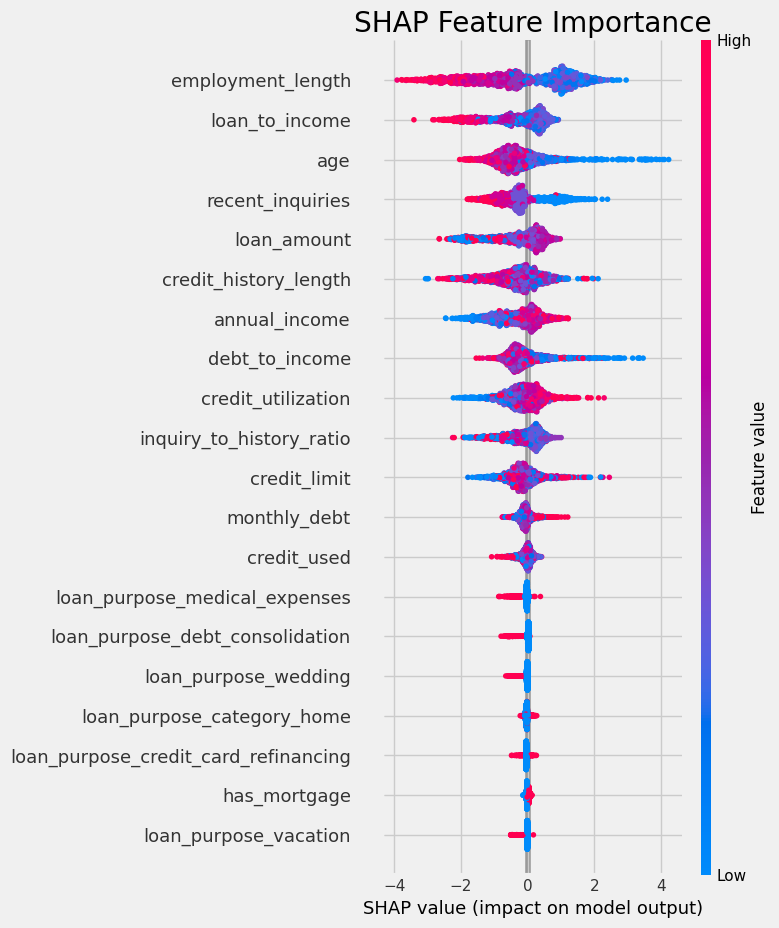

<Figure size 640x480 with 0 Axes>

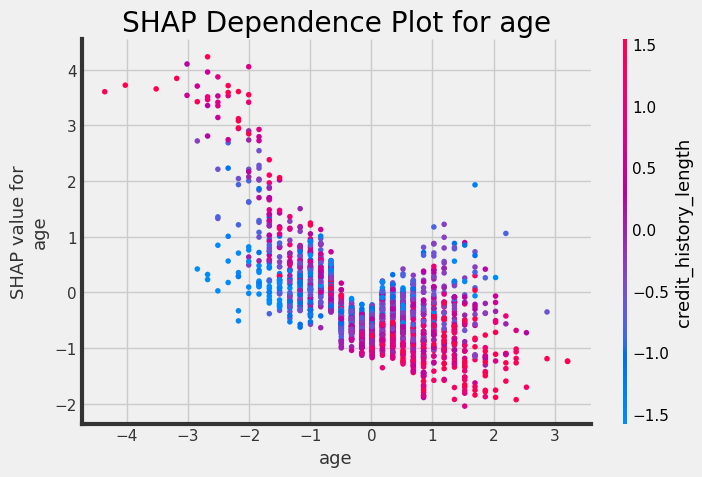

<Figure size 640x480 with 0 Axes>

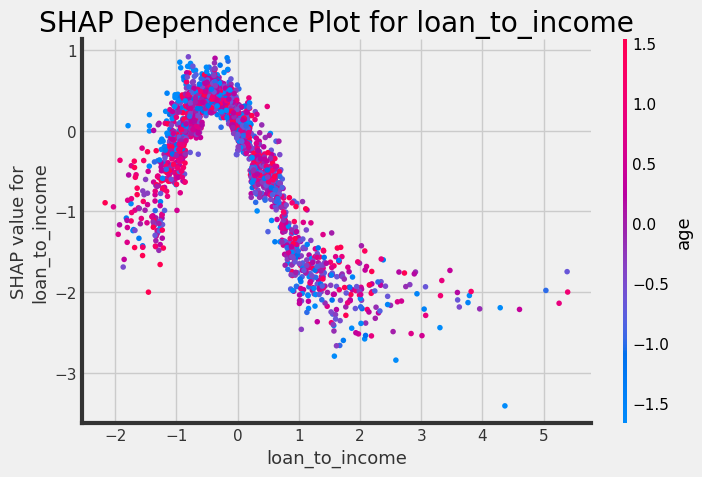

<Figure size 640x480 with 0 Axes>

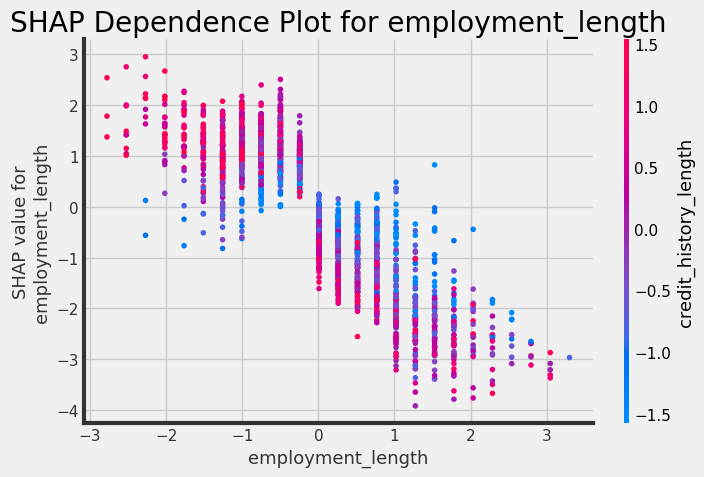

In [19]:
# Get feature names after preprocessing
preprocessor.fit(X)
cat_features = preprocessor.transformers_[1][1]['onehot'].get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_features])

# Get feature importance from Random Forest model
rf_model = models['Random Forest'].named_steps['classifier']
rf_importances = rf_model.feature_importances_

# Sort feature importances
rf_indices = np.argsort(rf_importances)[::-1]

# Plot top 20 feature importances
plt.figure(figsize=(12, 8))
plt.title('Random Forest Feature Importance')
plt.bar(range(20), rf_importances[rf_indices][:20], align='center')
plt.xticks(range(20), feature_names[rf_indices][:20], rotation=90)
plt.tight_layout()
plt.show()

# Get feature importance from XGBoost
xgb_model = models['XGBoost'].named_steps['classifier']
xgb_importance_type = 'gain'  # Options: 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
xgb_importances = xgb_model.get_booster().get_score(importance_type=xgb_importance_type)

# Convert to DataFrame for plotting
xgb_importance_df = pd.DataFrame({
    'Feature': list(xgb_importances.keys()),
    'Importance': list(xgb_importances.values())
}).sort_values('Importance', ascending=False)

# Map feature indices to feature names and plot top 20
plt.figure(figsize=(12, 8))
plt.title('XGBoost Feature Importance (Gain)')
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(20))
plt.tight_layout()
plt.show()

# SHAP values for model interpretation (if available)
try:
    import shap
    
    # Create explainer for the XGBoost model
    # Note: We need to preprocess the test data first
    X_test_processed = preprocessor.transform(X_test)
    
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_processed)
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    plt.show()
    
    # Dependency plots for top features
    top_features_idx = np.argsort(np.mean(np.abs(shap_values), axis=0))[-3:]
    for idx in top_features_idx:
        plt.figure()
        shap.dependence_plot(idx, shap_values, X_test_processed, feature_names=feature_names, show=False)
        plt.title(f'SHAP Dependence Plot for {feature_names[idx]}')
        plt.tight_layout()
        plt.show()
        
except ImportError:
    print("SHAP library not available. Install it using 'pip install shap'")

### 2.8 Business Impact Analysis

Cost Analysis for XGBoost:
False Positives: 128 (Cost: $256,000.00)
False Negatives: 39 (Cost: $216,265.80)
Total Cost: $472,265.80

Baseline Cost (approve all): $2,432,000.06
Cost Savings: $1,959,734.26


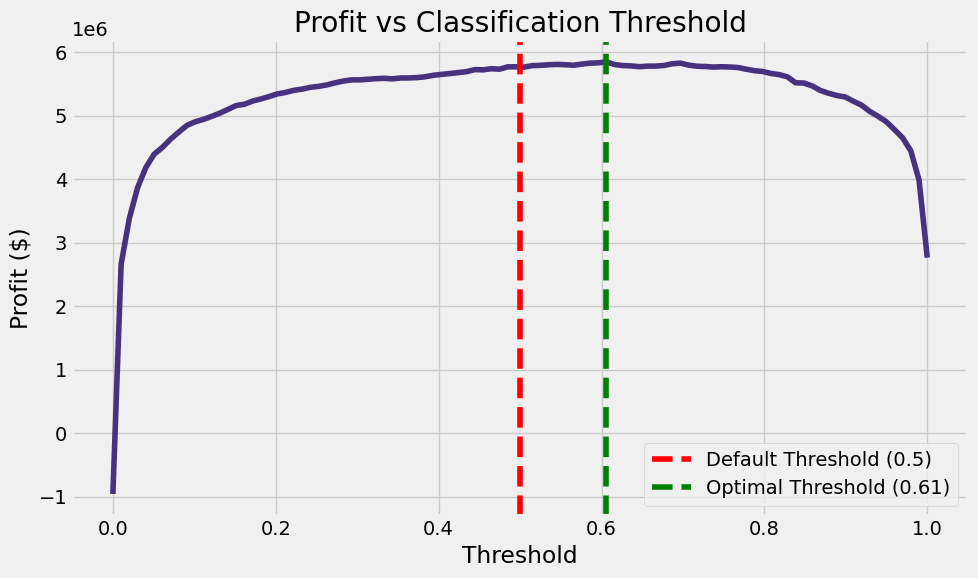

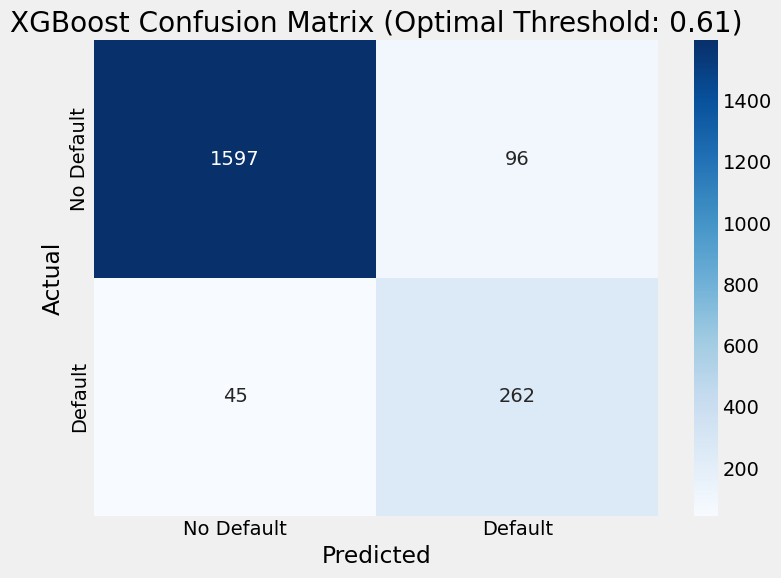


Metrics with Optimal Threshold (0.61):
Precision: 0.7318
Recall: 0.8534
F1 Score: 0.7880
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1693
           1       0.73      0.85      0.79       307

    accuracy                           0.93      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.94      0.93      0.93      2000



In [20]:
# Let's calculate the financial impact of our model

# Define costs and benefits
avg_loan_amount = df['loan_amount'].mean()
cost_per_default = avg_loan_amount * 0.3  # Assuming 30% loss given default
cost_per_false_positive = 2000  # Lost revenue opportunity
cost_per_false_negative = cost_per_default * 0.7  # 70% of default cost

# Choose the best model
best_model_name = 'XGBoost'  # Based on previous evaluation
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate confusion matrix elements
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate costs
false_positive_cost = fp * cost_per_false_positive
false_negative_cost = fn * cost_per_false_negative
total_cost = false_positive_cost + false_negative_cost

print(f"Cost Analysis for {best_model_name}:")
print(f"False Positives: {fp} (Cost: ${false_positive_cost:,.2f})")
print(f"False Negatives: {fn} (Cost: ${false_negative_cost:,.2f})")
print(f"Total Cost: ${total_cost:,.2f}")

# Calculate baseline cost (if we approved all loans)
baseline_defaults = np.sum(y_test)
baseline_cost = baseline_defaults * cost_per_default
print(f"\nBaseline Cost (approve all): ${baseline_cost:,.2f}")
print(f"Cost Savings: ${baseline_cost - total_cost:,.2f}")

# Calculate the profit threshold curve
thresholds = np.linspace(0, 1, 100)
profits = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    # Revenue from true negatives (good loans we approved)
    revenue_tn = tn_t * (avg_loan_amount * 0.1)  # Assuming 10% profit margin
    
    # Cost of false positives (denied good loans)
    cost_fp = fp_t * cost_per_false_positive
    
    # Cost of false negatives (bad loans we approved)
    cost_fn = fn_t * cost_per_false_negative
    
    # Revenue from true positives (correctly denied bad loans)
    revenue_tp = tp_t * cost_per_default  # Avoided losses
    
    profit = revenue_tn + revenue_tp - cost_fp - cost_fn
    profits.append(profit)

# Plot profit vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits)
plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')

# Find optimal threshold
optimal_threshold = thresholds[np.argmax(profits)]
plt.axvline(x=optimal_threshold, color='green', linestyle='--', 
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('Profit vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Profit ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Recalculate predictions with optimal threshold
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

# Display confusion matrix with optimal threshold
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.title(f'{best_model_name} Confusion Matrix (Optimal Threshold: {optimal_threshold:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Calculate metrics with optimal threshold
from sklearn.metrics import precision_score, recall_score, f1_score

precision_optimal = precision_score(y_test, y_pred_optimal)
recall_optimal = recall_score(y_test, y_pred_optimal)
f1_optimal = f1_score(y_test, y_pred_optimal)

print(f"\nMetrics with Optimal Threshold ({optimal_threshold:.2f}):")
print(f"Precision: {precision_optimal:.4f}")
print(f"Recall: {recall_optimal:.4f}")
print(f"F1 Score: {f1_optimal:.4f}")
print(classification_report(y_test, y_pred_optimal))

## 3. Clustering: Customer Segmentation for E-commerce

### 3.1 Problem Definition
In this advanced case study, we'll develop a customer segmentation strategy for an e-commerce platform using clustering techniques. The goal is to identify distinct customer groups based on their shopping behavior, allowing for personalized marketing strategies and improved customer experience.

### 3.2 Dataset
We'll use the Online Retail II dataset, a rich transactional dataset containing all purchases made by customers of a UK-based online retailer between 2009 and 2011.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# Load the Online Retail II dataset (available at: https://archive.ics.uci.edu/ml/datasets/online+retail+II)
df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011", engine='openpyxl')

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (541910, 8)
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  


### 3.3 Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Summary statistics:
            Quantity                    InvoiceDate          Price  \
count  541910.000000                         541910  541910.000000   
mean        9.552234  2011-07-04 13:35:22.342307584       4.611138   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25

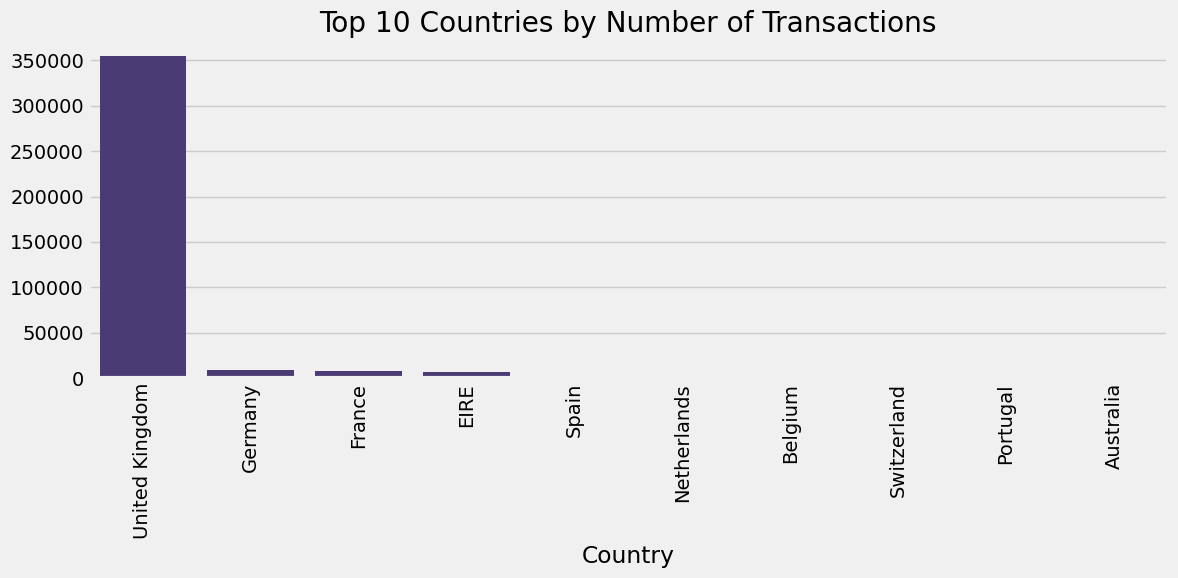

UK data shape: (354321, 8)

RFM summary:
           Recency    Frequency       Monetary
count  3920.000000  3920.000000    3920.000000
mean     92.208418     4.246429    1864.385601
std      99.533854     7.199202    7482.817477
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     300.280000
50%      51.000000     2.000000     652.280000
75%     143.000000     5.000000    1576.585000
max     374.000000   209.000000  259657.300000


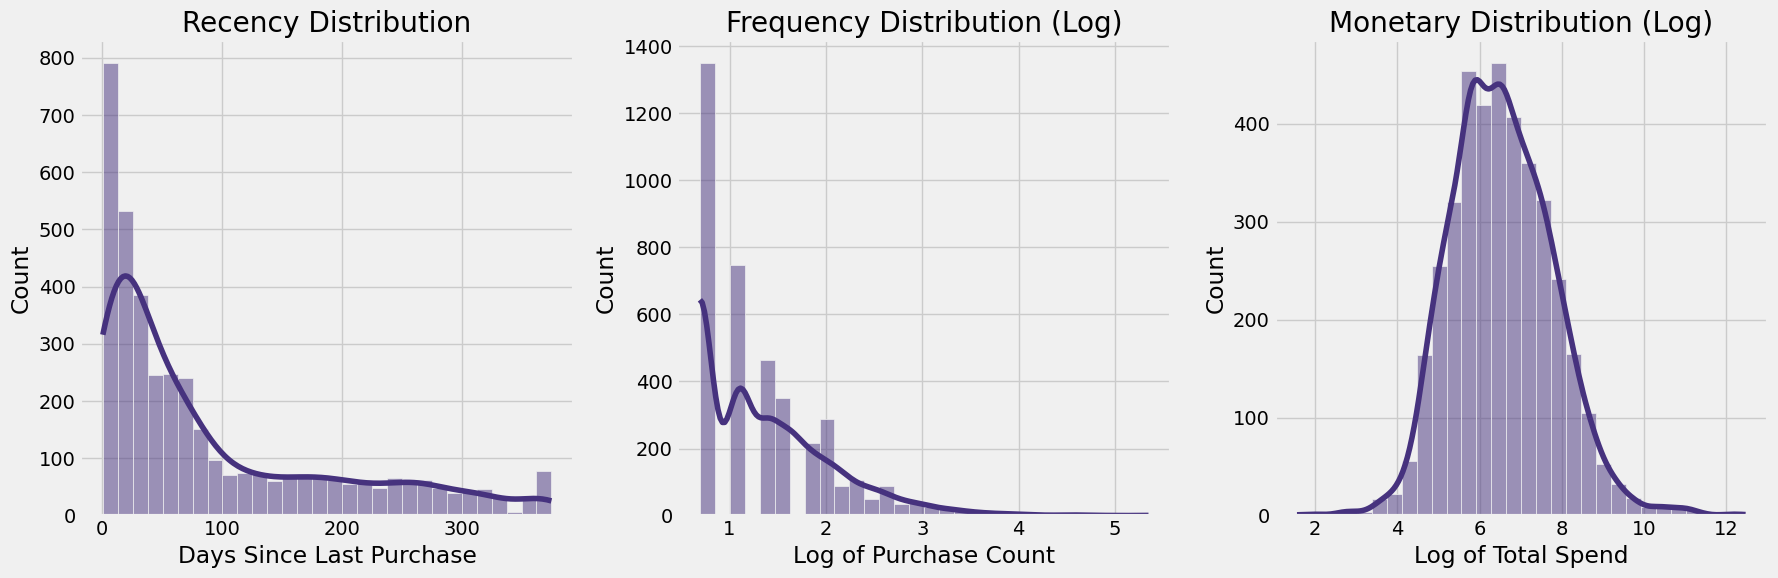

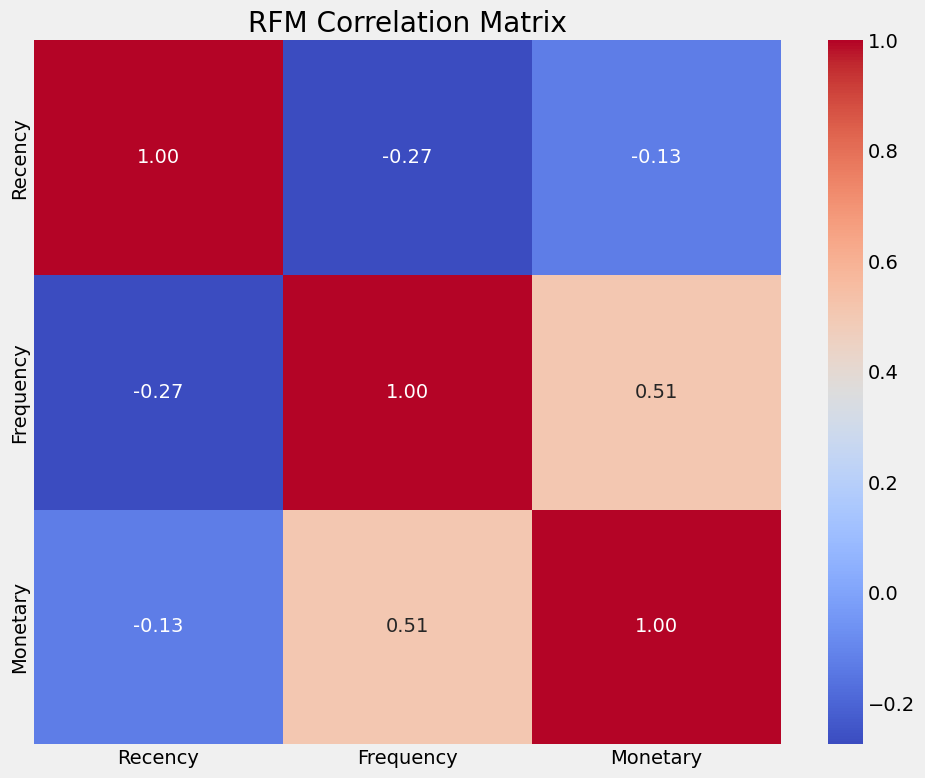

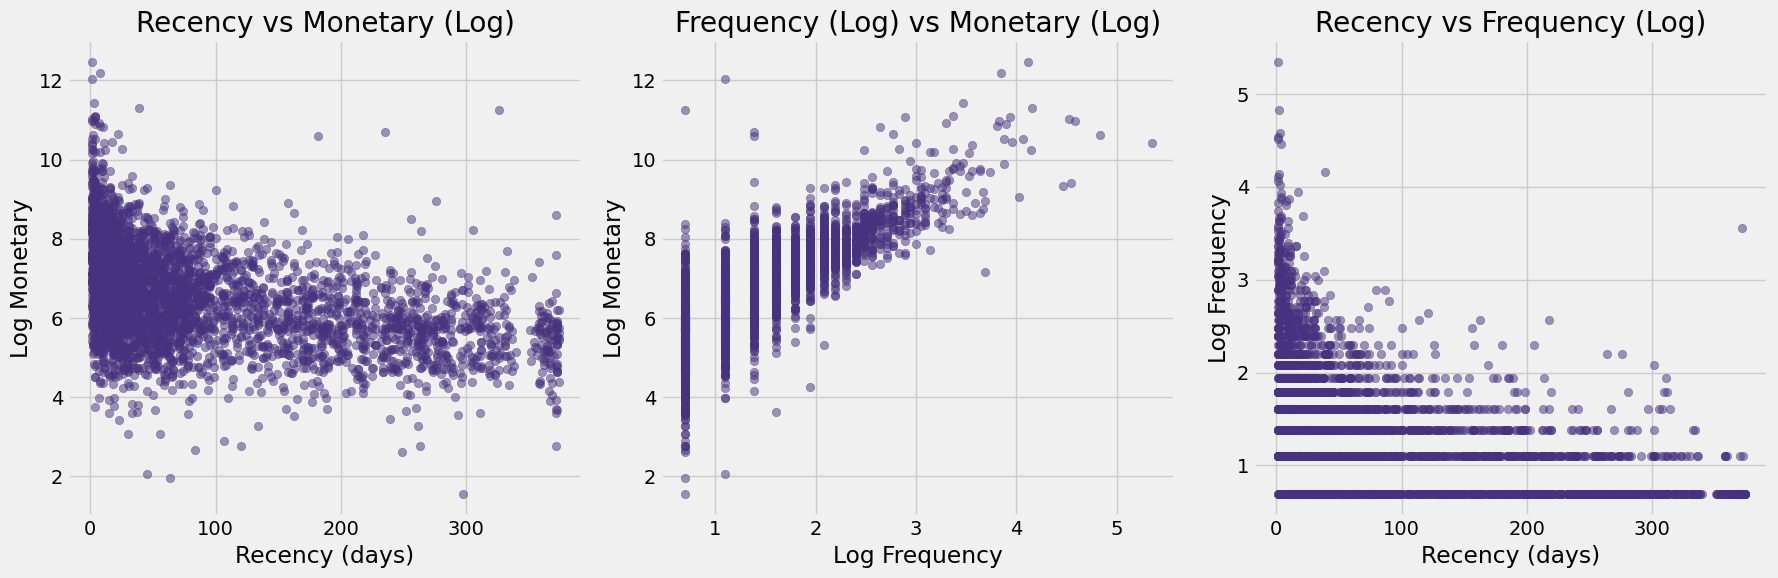

In [22]:
# Basic information
print(df.info())
print("\nSummary statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Clean the data: remove rows with missing values and negative quantities or prices
df = df.dropna()
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Examine the distribution of countries
plt.figure(figsize=(12, 6))
country_counts = df['Country'].value_counts()
top_countries = country_counts.head(10)
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.xticks(rotation=90)
plt.title('Top 10 Countries by Number of Transactions')
plt.tight_layout()
plt.show()

# Focus on UK market (largest segment)
df_uk = df[df['Country'] == 'United Kingdom']
print(f"UK data shape: {df_uk.shape}")

# Convert InvoiceDate to datetime
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])

# Extract RFM features (Recency, Frequency, Monetary)
# Set the snapshot date as one day after the last transaction date
snapshot_date = df_uk['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by customer and calculate RFM metrics
rfm = df_uk.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                    # Frequency
    'Price': lambda x: (x * df_uk.loc[x.index, 'Quantity']).sum()  # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Check RFM summary
print("\nRFM summary:")
print(rfm.describe())

# Visualize the distribution of RFM values
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Recency Distribution')
plt.xlabel('Days Since Last Purchase')

plt.subplot(1, 3, 2)
sns.histplot(np.log1p(rfm['Frequency']), bins=30, kde=True)
plt.title('Frequency Distribution (Log)')
plt.xlabel('Log of Purchase Count')

plt.subplot(1, 3, 3)
sns.histplot(np.log1p(rfm['Monetary']), bins=30, kde=True)
plt.title('Monetary Distribution (Log)')
plt.xlabel('Log of Total Spend')

plt.tight_layout()
plt.show()

# Examine correlations between RFM metrics
plt.figure(figsize=(10, 8))
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('RFM Correlation Matrix')
plt.tight_layout()
plt.show()

# Scatter plot to visualize relationships
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(rfm['Recency'], np.log1p(rfm['Monetary']), alpha=0.5)
plt.title('Recency vs Monetary (Log)')
plt.xlabel('Recency (days)')
plt.ylabel('Log Monetary')

plt.subplot(1, 3, 2)
plt.scatter(np.log1p(rfm['Frequency']), np.log1p(rfm['Monetary']), alpha=0.5)
plt.title('Frequency (Log) vs Monetary (Log)')
plt.xlabel('Log Frequency')
plt.ylabel('Log Monetary')

plt.subplot(1, 3, 3)
plt.scatter(rfm['Recency'], np.log1p(rfm['Frequency']), alpha=0.5)
plt.title('Recency vs Frequency (Log)')
plt.xlabel('Recency (days)')
plt.ylabel('Log Frequency')

plt.tight_layout()
plt.show()

### 3.4 Advanced Feature Engineering for E-commerce

In [23]:
# Add additional features for deeper customer understanding
df_uk['TotalAmount'] = df_uk['Quantity'] * df_uk['Price']
df_uk['Month'] = df_uk['InvoiceDate'].dt.month
df_uk['DayOfWeek'] = df_uk['InvoiceDate'].dt.dayofweek
df_uk['Hour'] = df_uk['InvoiceDate'].dt.hour

# Calculate customer metrics
customer_metrics = df_uk.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                    # Frequency
    'TotalAmount': 'sum',                                    # Monetary
    'Quantity': 'sum',                                       # Total items purchased
    'StockCode': 'nunique',                                  # Product variety
    'Month': lambda x: x.mode().iloc[0] if not x.empty else 0,  # Most common purchase month
    'DayOfWeek': lambda x: x.mode().iloc[0] if not x.empty else 0,  # Most common purchase day
    'Hour': lambda x: x.mode().iloc[0] if not x.empty else 0,  # Most common purchase hour
})

# Rename columns
customer_metrics.columns = ['Recency', 'Frequency', 'Monetary', 'ItemCount', 
                            'ProductVariety', 'PrefMonth', 'PrefDay', 'PrefHour']

# Calculate average order value
customer_metrics['AvgOrderValue'] = customer_metrics['Monetary'] / customer_metrics['Frequency']

# Calculate purchase variability (standard deviation of order amounts)
order_amounts = df_uk.groupby(['Customer ID', 'Invoice'])['TotalAmount'].sum().reset_index()
order_std = order_amounts.groupby('Customer ID')['TotalAmount'].std().fillna(0)
customer_metrics['OrderVariability'] = order_std

# Fill NaN values
customer_metrics = customer_metrics.fillna(0)

# Display customer metrics
print("\nCustomer metrics summary:")
print(customer_metrics.describe())

# Filter out outliers for better visualization and modeling
customer_metrics = customer_metrics[(customer_metrics['Monetary'] < customer_metrics['Monetary'].quantile(0.99)) &
                                    (customer_metrics['Frequency'] < customer_metrics['Frequency'].quantile(0.99)) &
                                    (customer_metrics['Recency'] < customer_metrics['Recency'].quantile(0.99))]

print(f"Customer metrics shape after removing outliers: {customer_metrics.shape}")


Customer metrics summary:
           Recency    Frequency       Monetary     ItemCount  ProductVariety  \
count  3920.000000  3920.000000    3920.000000   3920.000000     3920.000000   
mean     92.208418     4.246429    1864.385601   1085.903061       60.726531   
std      99.533854     7.199202    7482.817477   3737.507828       81.670816   
min       1.000000     1.000000       3.750000      1.000000        1.000000   
25%      18.000000     1.000000     300.280000    154.000000       15.000000   
50%      51.000000     2.000000     652.280000    365.000000       35.000000   
75%     143.000000     5.000000    1576.585000    950.250000       77.000000   
max     374.000000   209.000000  259657.300000  80997.000000     1768.000000   

         PrefMonth      PrefDay     PrefHour  AvgOrderValue  OrderVariability  
count  3920.000000  3920.000000  3920.000000    3920.000000       3920.000000  
mean      7.623980     2.569133    12.550510     393.327827        159.469305  
std       3.

### 3.5 Data Preprocessing for Clustering

Scaled features summary:
           Recency    Frequency      Monetary    ItemCount  ProductVariety  \
count  3818.000000  3818.000000  3.818000e+03  3818.000000     3818.000000   
mean      0.325840     0.242296  2.242058e-02     0.007281       -0.035207   
std       0.796427     0.683670  7.153855e-01     0.727177        0.713616   
min      -0.416667    -0.442507 -3.031211e+00    -2.939850       -1.839576   
25%      -0.275000    -0.442507 -4.691325e-01    -0.478656       -0.516116   
50%       0.000000     0.000000 -2.741947e-16     0.000000        0.000000   
75%       0.725000     0.557493  5.308675e-01     0.521344        0.483884   
max       2.641667     2.475943  2.029359e+00     2.180711        1.905748   

       AvgOrderValue  OrderVariability  
count    3818.000000      3.818000e+03  
mean       -0.057256     -1.961474e-01  
std         0.813052      4.737684e-01  
min        -4.931770     -8.031984e-01  
25%        -0.559753     -8.031984e-01  
50%         0.000000      

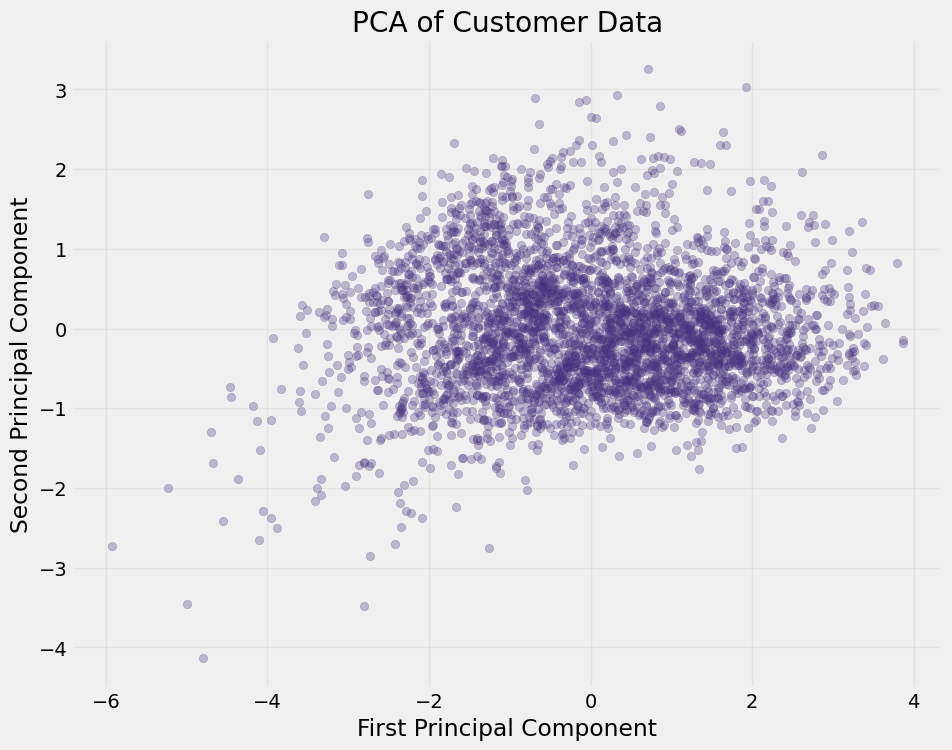

Variance explained by the first two components: 0.7987


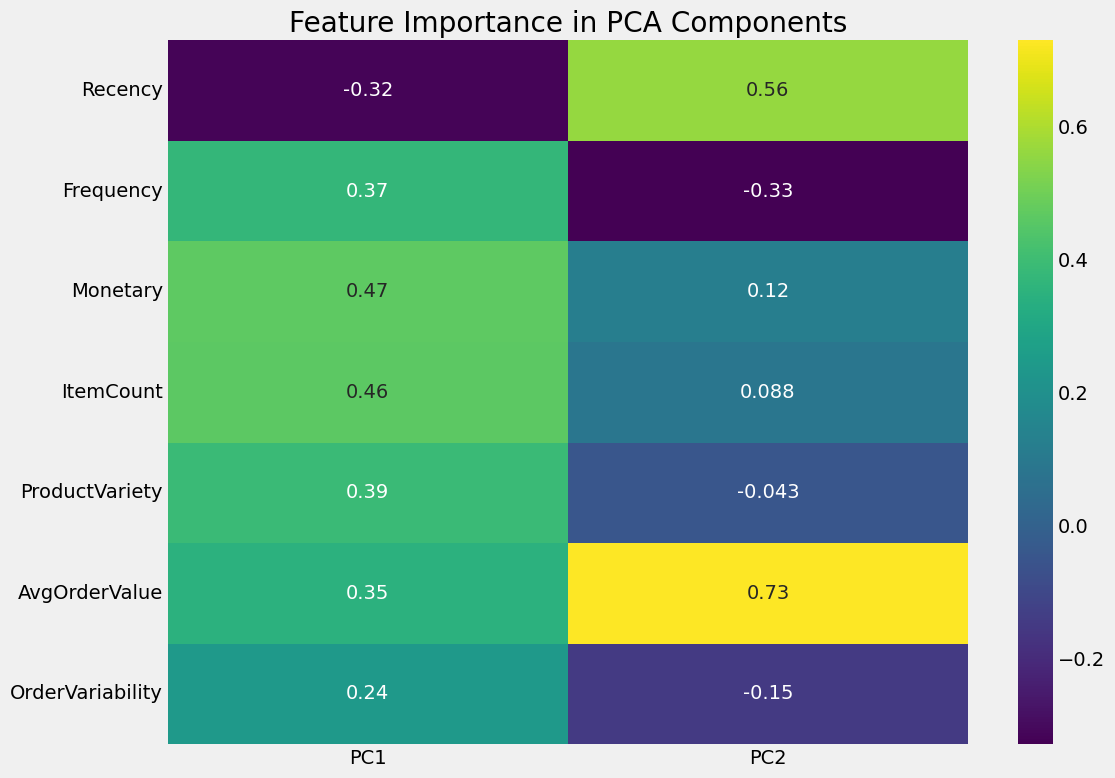

In [24]:
# Select features for clustering
features = ['Recency', 'Frequency', 'Monetary', 'ItemCount', 'ProductVariety', 
            'AvgOrderValue', 'OrderVariability']
X = customer_metrics[features].copy()

# Apply log transformation to highly skewed features
for col in ['Frequency', 'Monetary', 'ItemCount', 'ProductVariety', 'AvgOrderValue', 'OrderVariability']:
    X[col] = np.log1p(X[col])

# Scale the features
scaler = RobustScaler()  # RobustScaler is less influenced by outliers
X_scaled = scaler.fit_transform(X)

# Create a DataFrame with scaled values for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)

print("Scaled features summary:")
print(X_scaled_df.describe())

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title('PCA of Customer Data')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Variance explained by the first two components: {sum(pca.explained_variance_ratio_):.4f}")

# Feature importance in PCA
pca_components = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(2)],
    index=features
)

plt.figure(figsize=(12, 8))
sns.heatmap(pca_components, annot=True, cmap='viridis')
plt.title('Feature Importance in PCA Components')
plt.tight_layout()
plt.show()

### 3.6 Advanced Clustering Approaches

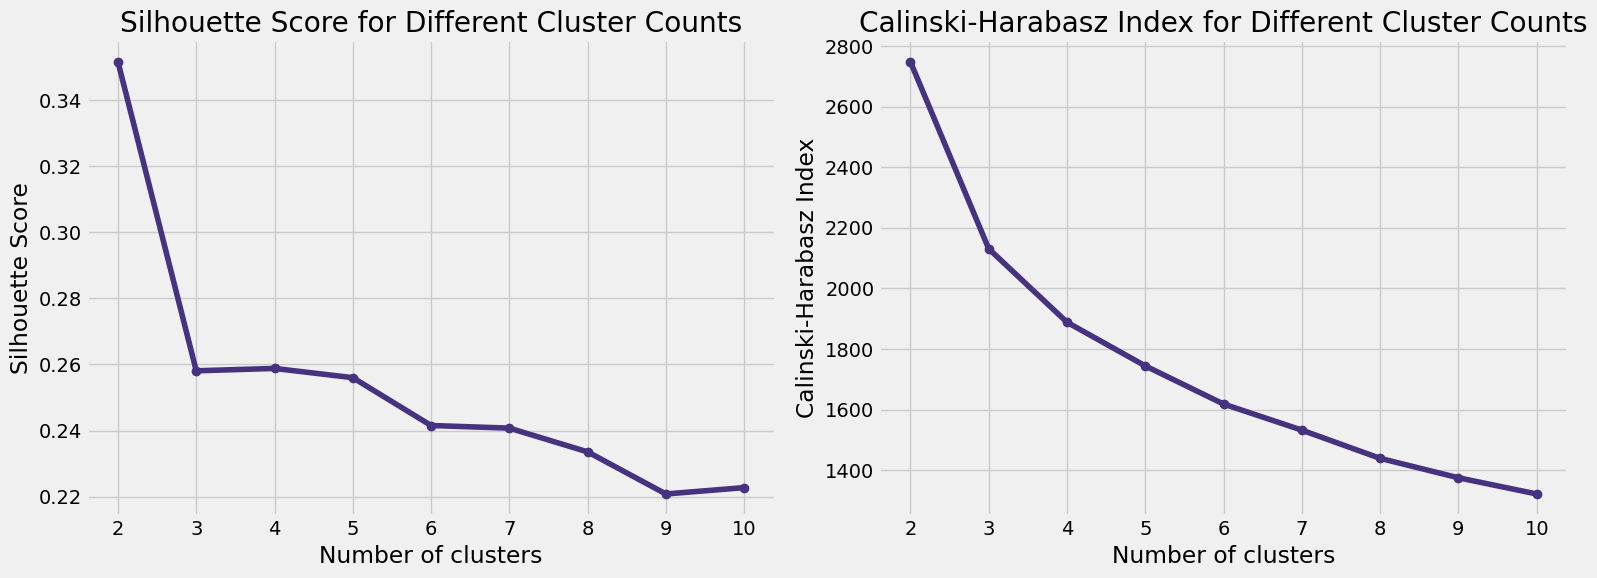

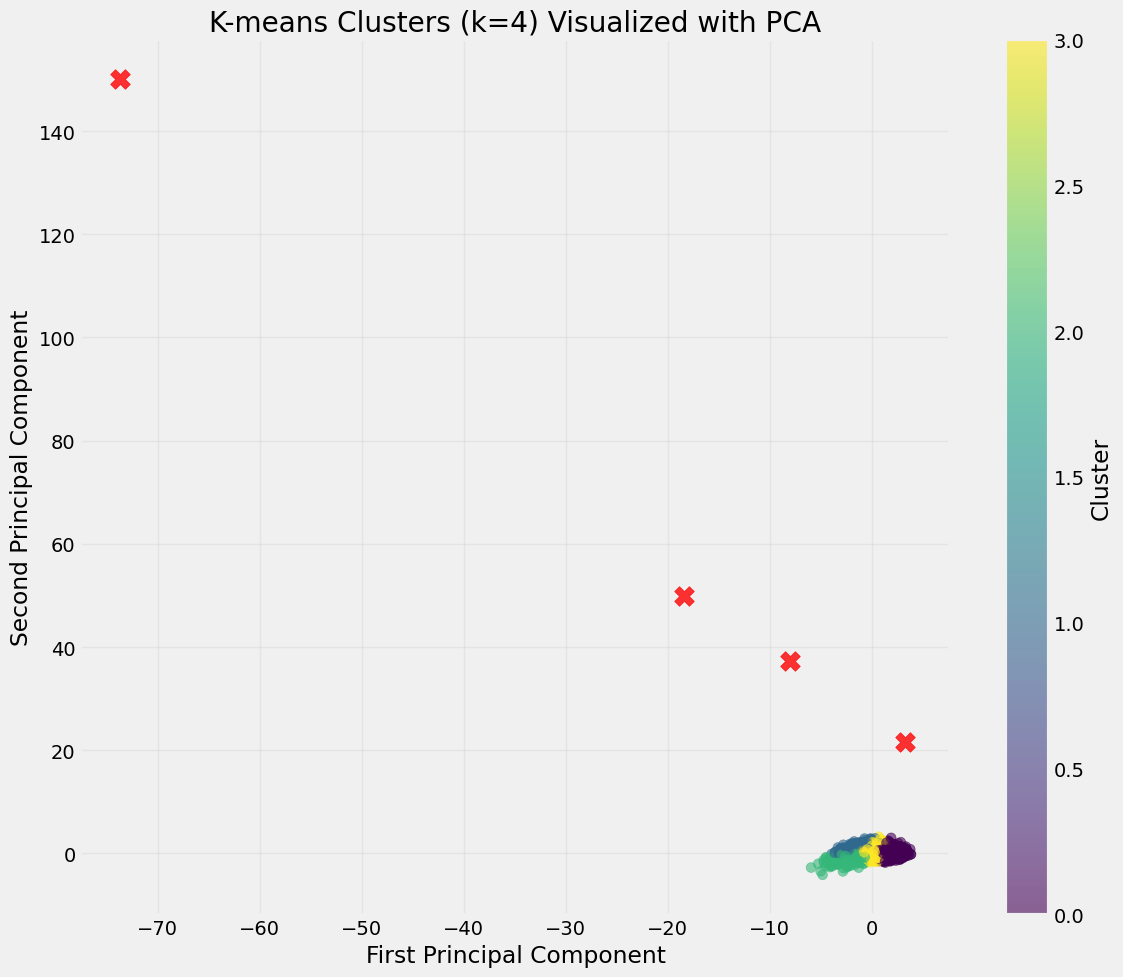

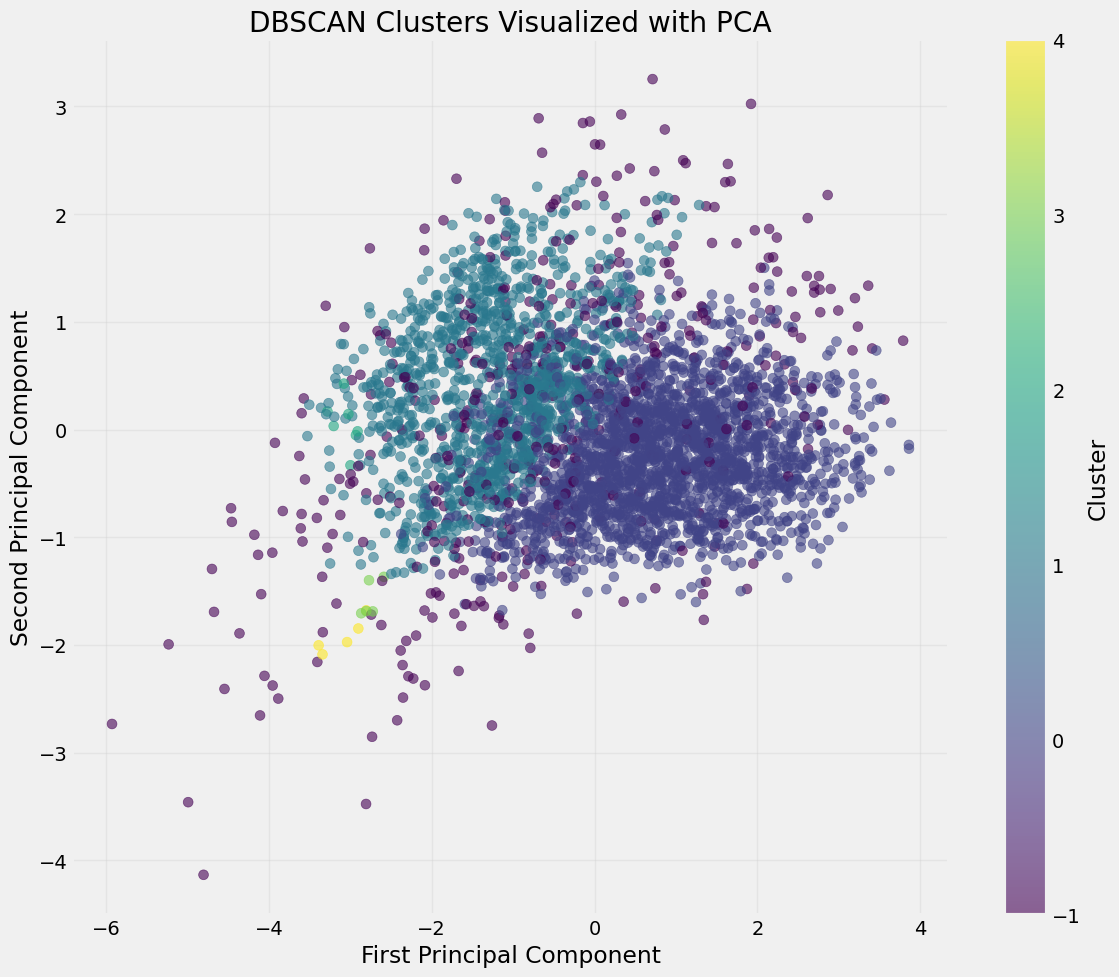

DBSCAN: Estimated number of clusters: 6
DBSCAN: Estimated number of noise points: 450


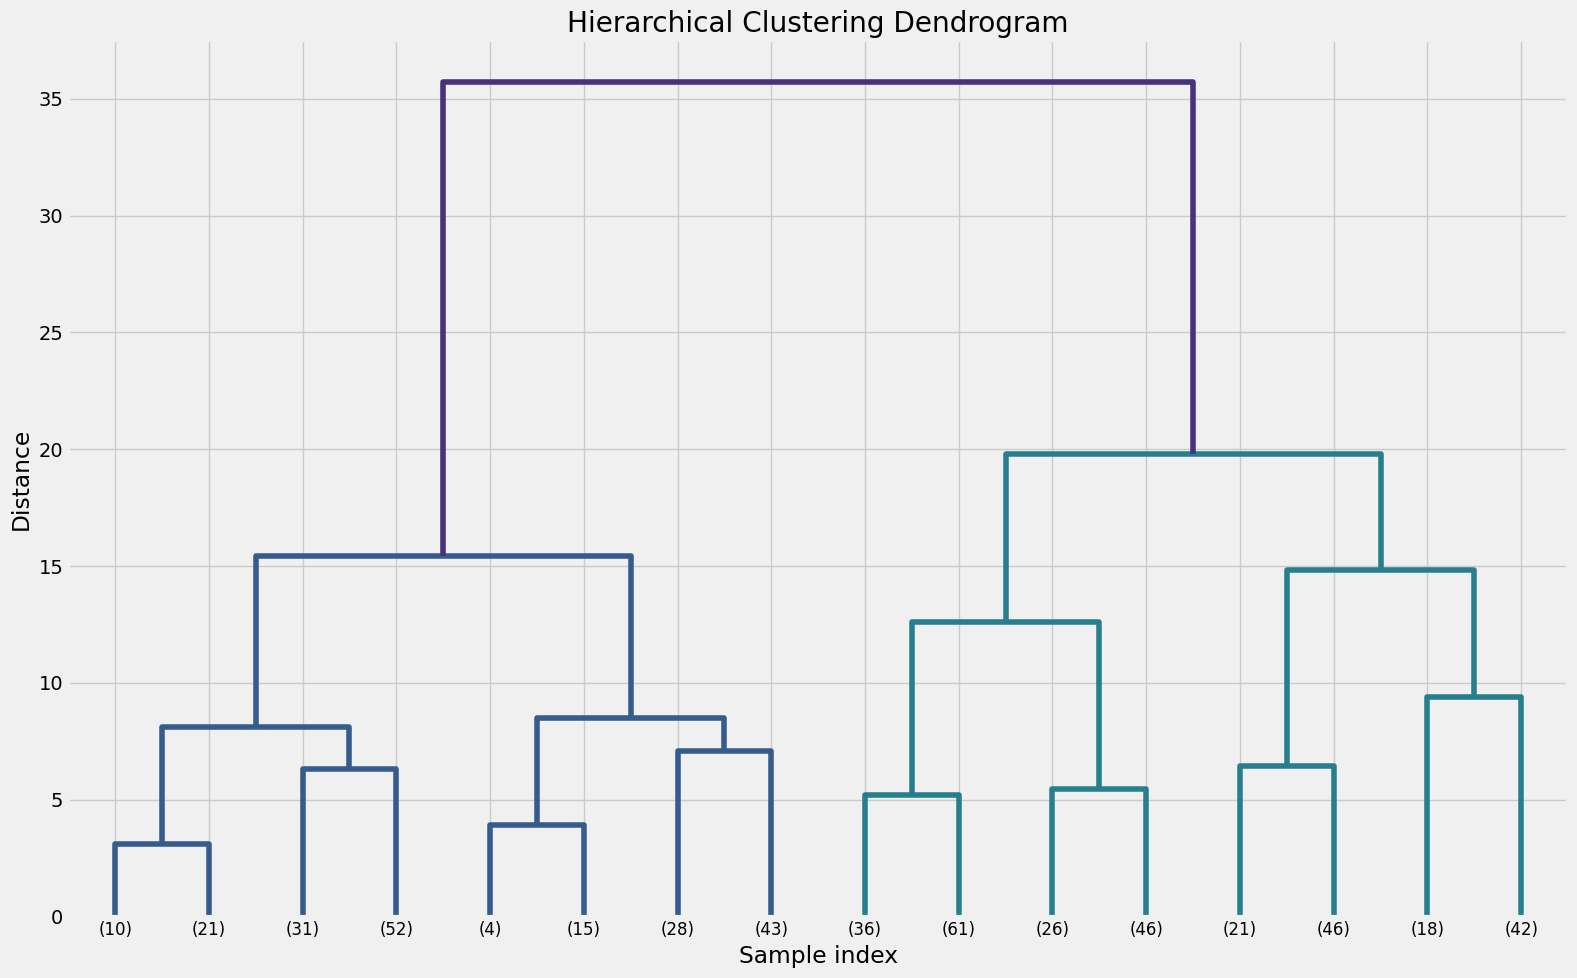

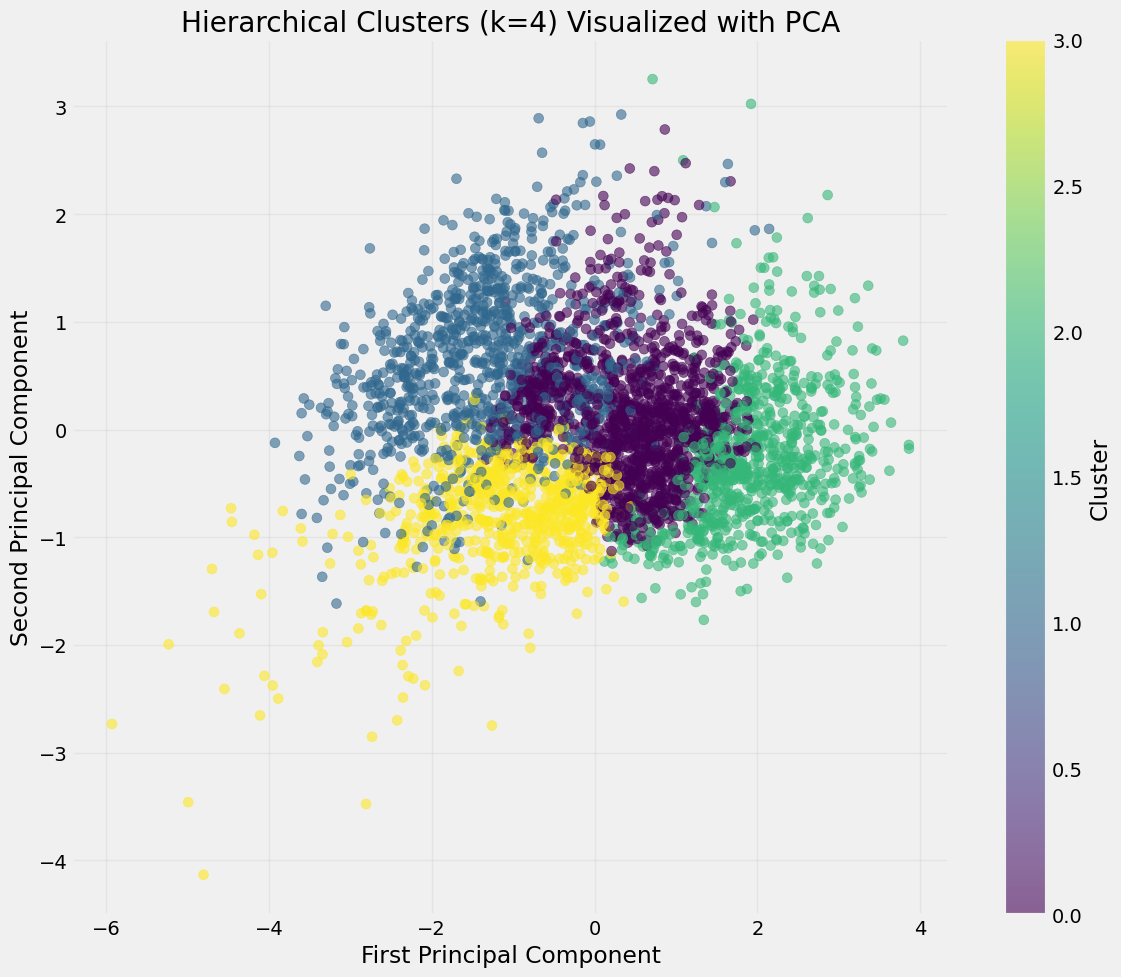

In [25]:
# Function to determine optimal K using silhouette score and Calinski-Harabasz index
def find_optimal_k(X, k_range):
    silhouette_scores = []
    ch_scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        silhouette_scores.append(silhouette_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))
    
    return silhouette_scores, ch_scores

# Find optimal K
k_range = range(2, 11)
silhouette_scores, ch_scores = find_optimal_k(X_scaled, k_range)

# Plot the scores
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Cluster Counts')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, ch_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index for Different Cluster Counts')
plt.grid(True)

plt.tight_layout()
plt.show()

# Based on the evaluation metrics, choose optimal k
optimal_k = 4  # Example value, adjust based on your results

# Apply K-means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_metrics['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Plot the clusters in PCA space
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_metrics['Cluster_KMeans'], 
                     cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-means Clusters (k={optimal_k}) Visualized with PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True, alpha=0.3)

# Add cluster centers to the plot (transform them to PCA space first)
centers = pca.transform(scaler.inverse_transform(kmeans.cluster_centers_))
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X')
plt.tight_layout()
plt.show()

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
customer_metrics['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN clusters
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_metrics['Cluster_DBSCAN'], 
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('DBSCAN Clusters Visualized with PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate the number of clusters and noise points
n_clusters = len(set(customer_metrics['Cluster_DBSCAN'])) - (1 if -1 in customer_metrics['Cluster_DBSCAN'] else 0)
n_noise = list(customer_metrics['Cluster_DBSCAN']).count(-1)
print(f'DBSCAN: Estimated number of clusters: {n_clusters}')
print(f'DBSCAN: Estimated number of noise points: {n_noise}')

# Apply hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
customer_metrics['Cluster_Hierarchical'] = hierarchical.fit_predict(X_scaled)

# Plot hierarchical clustering dendrogram (using a sample for clarity)
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and plot
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                     counts]).astype(float)
    
    # Plot the dendrogram
    dendrogram(linkage_matrix, **kwargs)

# Create a sample for visualization (hierarchical dendrogram can be cluttered with too many points)
sample_indices = np.random.choice(X_scaled.shape[0], size=min(500, X_scaled.shape[0]), replace=False)
X_sample = X_scaled[sample_indices]

# Fit hierarchical clustering for dendrogram
hierarchical_sample = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward', 
                                              compute_distances=True)
hierarchical_sample.fit(X_sample)

# Plot dendrogram
plt.figure(figsize=(16, 10))
plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(hierarchical_sample, truncate_mode='level', p=3)
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Plot hierarchical clusters
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_metrics['Cluster_Hierarchical'], 
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Hierarchical Clusters (k={optimal_k}) Visualized with PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 Advanced Cluster Analysis and Customer Segmentation


Cluster analysis based on K-means:
                Recency  Frequency  Monetary  ItemCount  ProductVariety  \
Cluster_KMeans                                                            
0                 31.12       8.26   3346.32    2020.96          127.82   
1                259.57       1.31    354.64     190.94           20.63   
2                 82.37       1.52    186.24     110.21           14.27   
3                 58.69       2.58    765.16     470.37           45.94   

                AvgOrderValue  OrderVariability  PrefMonth  PrefDay  PrefHour  
Cluster_KMeans                                                                 
0                      462.04            245.27         11        3        12  
1                      289.57             21.98          3        3        13  
2                      135.54             15.26         11        3        12  
3                      359.39             94.76         11        3        12  

Cluster sizes:
Cluster_KMeans
3 

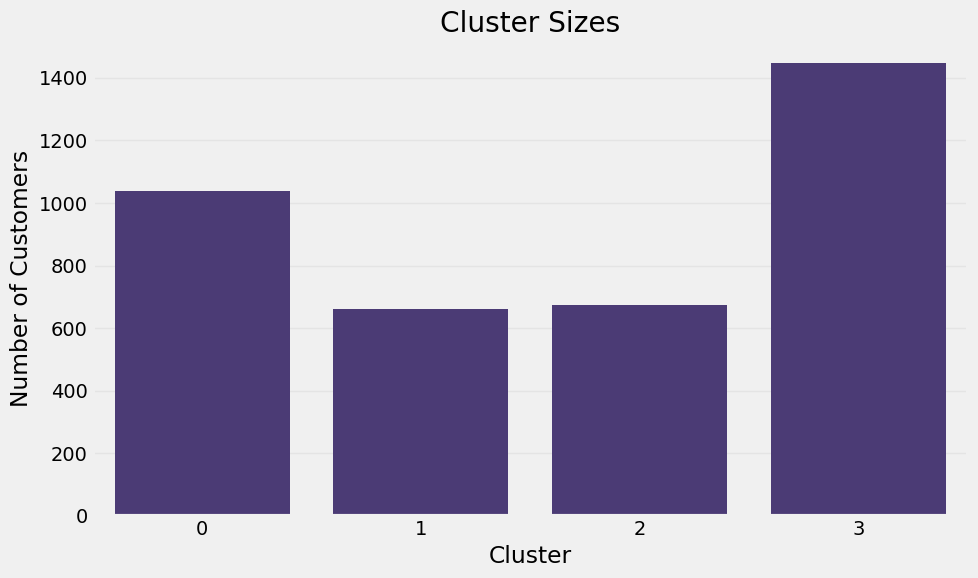

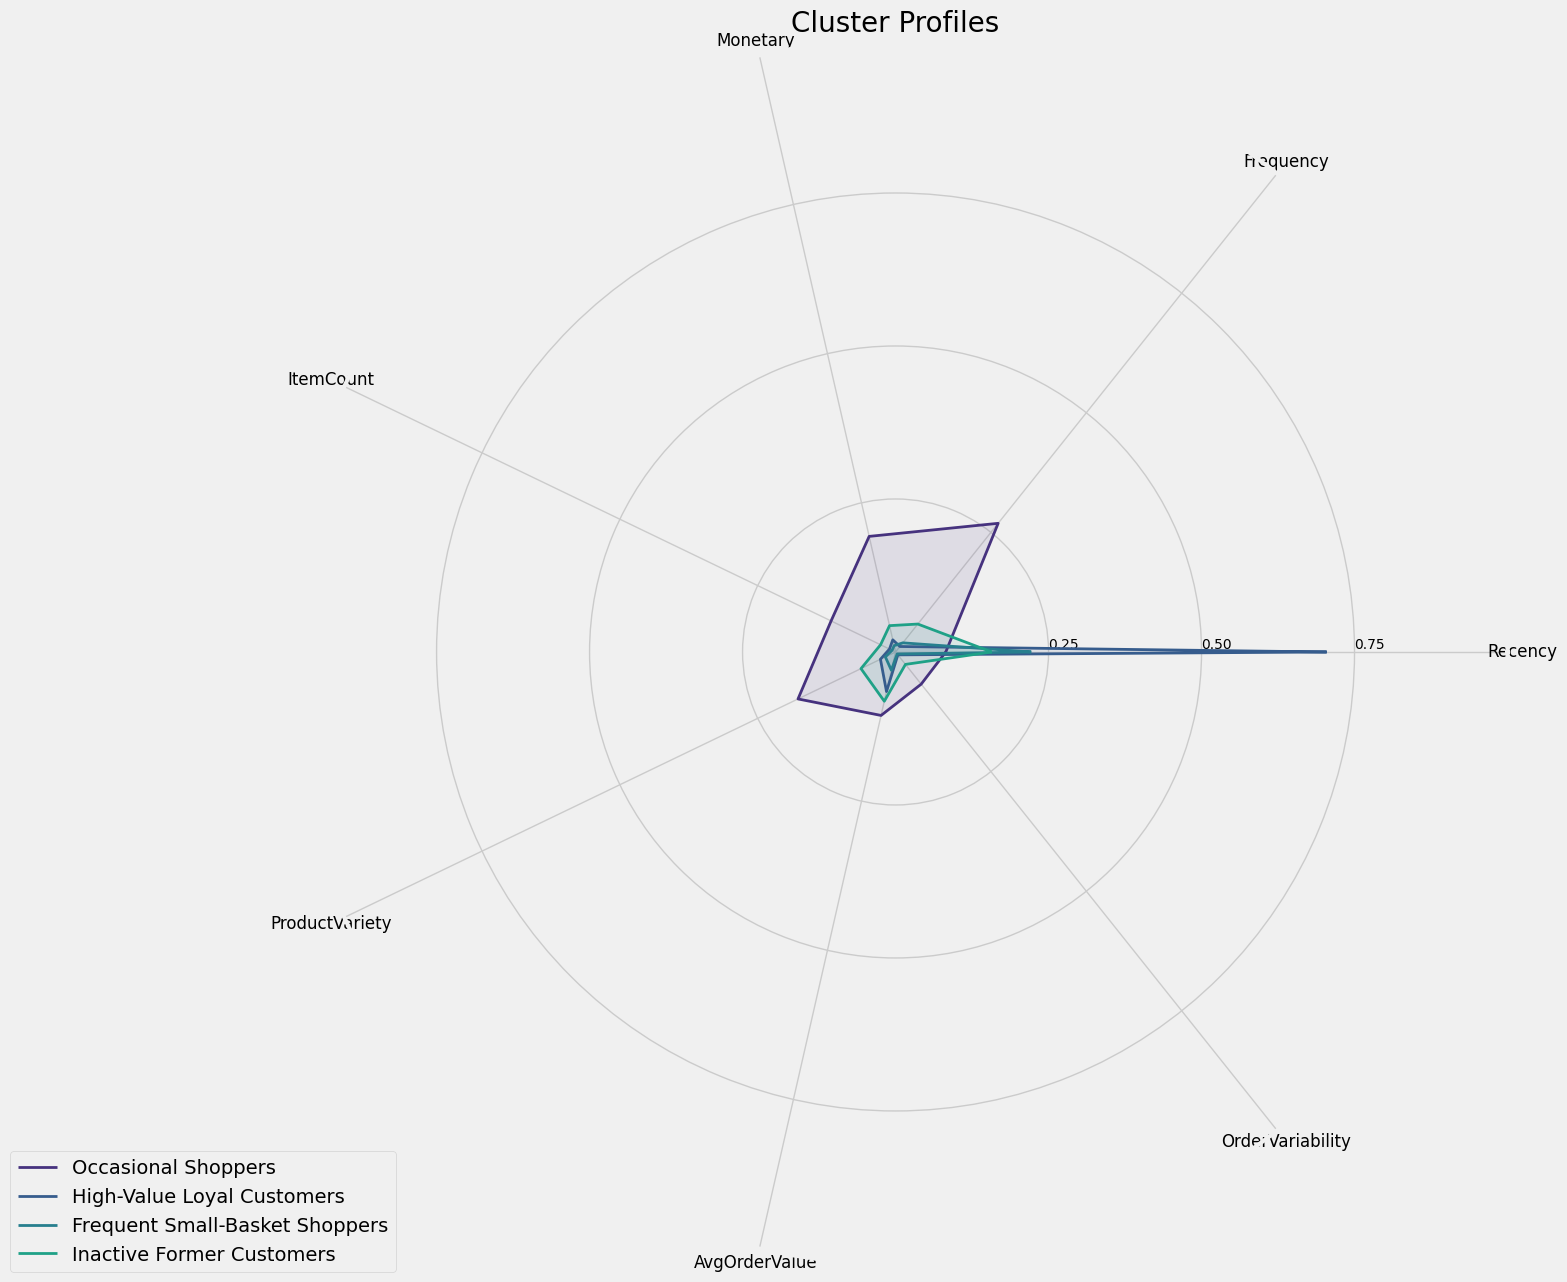


Customer Segments and Marketing Recommendations:

Occasional Shoppers (Cluster 0):
Size: 1037 customers (27.2% of total)
Average days since last purchase: 31.1
Average number of purchases: 8.3
Average total spend: £3346.32
Average order value: £462.04
Preferred shopping day: Thursday
Preferred shopping hour: 12:00

Marketing Recommendations:
- Send periodic reminders and special offers to encourage more frequent visits
- Focus on increasing engagement through personalized product recommendations
- Consider loyalty program to incentivize repeat purchases
- Target with emails/ads on their preferred shopping day (just before their preferred hour)

High-Value Loyal Customers (Cluster 1):
Size: 660 customers (17.3% of total)
Average days since last purchase: 259.6
Average number of purchases: 1.3
Average total spend: £354.64
Average order value: £289.57
Preferred shopping day: Thursday
Preferred shopping hour: 13:00

Marketing Recommendations:
- VIP treatment with early access to new produ

In [26]:
# Analyze each cluster from K-means (most interpretable)
cluster_analysis = customer_metrics.groupby('Cluster_KMeans').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'ItemCount': 'mean',
    'ProductVariety': 'mean',
    'AvgOrderValue': 'mean',
    'OrderVariability': 'mean',
    'PrefMonth': lambda x: x.mode().iloc[0],
    'PrefDay': lambda x: x.mode().iloc[0],
    'PrefHour': lambda x: x.mode().iloc[0]
}).round(2)

print("\nCluster analysis based on K-means:")
print(cluster_analysis)

# Convert preferred day number to day name for better interpretability
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
           3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
cluster_analysis['PrefDay'] = cluster_analysis['PrefDay'].map(day_map)

# Convert month number
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
cluster_analysis['PrefMonth'] = cluster_analysis['PrefMonth'].map(month_map)

# Calculate cluster sizes
cluster_sizes = customer_metrics['Cluster_KMeans'].value_counts()
print("\nCluster sizes:")
print(cluster_sizes)

# Visualize the cluster sizes
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values)
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize cluster characteristics using radar charts
from math import pi

def radar_chart(df, cluster_col, value_cols, cluster_names=None):
    # Number of variables
    categories = value_cols
    N = len(categories)
    
    # What will be the angle of each axis in the plot
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Initialize the figure
    fig, ax = plt.subplots(figsize=(15, 15), subplot_kw=dict(polar=True))
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, size=12)
    
    # Set y-ticks
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], size=10)
    plt.ylim(0, 1)
    
    # Cluster names if provided
    if cluster_names is None:
        cluster_names = {i: f"Cluster {i}" for i in sorted(df[cluster_col].unique())}
    
    # Plot each cluster
    for cluster_id in sorted(df[cluster_col].unique()):
        # Get data for this cluster
        values = df[df[cluster_col] == cluster_id][value_cols].mean().values.flatten().tolist()
        
        # Scale values to [0,1]
        min_vals = df[value_cols].min().values
        max_vals = df[value_cols].max().values
        values = [(v - min_v) / (max_v - min_v) for v, min_v, max_v in zip(values, min_vals, max_vals)]
        
        # Make sure the plot closes
        values += values[:1]
        
        # Plot values
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_names[cluster_id])
        ax.fill(angles, values, alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title("Cluster Profiles", size=20)
    
    return fig, ax

# Prepare data for radar chart (select numerical features only)
radar_features = ['Recency', 'Frequency', 'Monetary', 'ItemCount', 
                 'ProductVariety', 'AvgOrderValue', 'OrderVariability']

# Define cluster names based on analysis
cluster_names = {
    0: "Occasional Shoppers",
    1: "High-Value Loyal Customers",
    2: "Frequent Small-Basket Shoppers",
    3: "Inactive Former Customers"
}

# Create radar chart
radar_chart(customer_metrics, 'Cluster_KMeans', radar_features, cluster_names)
plt.tight_layout()
plt.show()

# Create segment profiles and marketing recommendations
print("\nCustomer Segments and Marketing Recommendations:")
segments = {}

for cluster_id, name in cluster_names.items():
    cluster_data = customer_metrics[customer_metrics['Cluster_KMeans'] == cluster_id]
    
    # Get key statistics
    avg_recency = cluster_data['Recency'].mean()
    avg_frequency = cluster_data['Frequency'].mean()
    avg_monetary = cluster_data['Monetary'].mean()
    avg_order_value = cluster_data['AvgOrderValue'].mean()
    pref_day = day_map[int(cluster_data['PrefDay'].mode().iloc[0])]
    pref_hour = int(cluster_data['PrefHour'].mode().iloc[0])
    count = len(cluster_data)
    percentage = count / len(customer_metrics) * 100
    
    print(f"\n{name} (Cluster {cluster_id}):")
    print(f"Size: {count} customers ({percentage:.1f}% of total)")
    print(f"Average days since last purchase: {avg_recency:.1f}")
    print(f"Average number of purchases: {avg_frequency:.1f}")
    print(f"Average total spend: £{avg_monetary:.2f}")
    print(f"Average order value: £{avg_order_value:.2f}")
    print(f"Preferred shopping day: {pref_day}")
    print(f"Preferred shopping hour: {pref_hour}:00")
    
    print("\nMarketing Recommendations:")
    
    if cluster_id == 0:  # Occasional Shoppers
        print("- Send periodic reminders and special offers to encourage more frequent visits")
        print("- Focus on increasing engagement through personalized product recommendations")
        print("- Consider loyalty program to incentivize repeat purchases")
        print("- Target with emails/ads on their preferred shopping day (just before their preferred hour)")
    
    elif cluster_id == 1:  # High-Value Loyal Customers
        print("- VIP treatment with early access to new products and exclusive offers")
        print("- Premium customer service and personalized shopping experiences")
        print("- Focus on retention and cross-selling premium products")
        print("- Implement referral program to leverage their network")
    
    elif cluster_id == 2:  # Frequent Small-Basket Shoppers
        print("- Bundle offers to increase average basket value")
        print("- Free shipping thresholds just above their typical order value")
        print("- Targeted cross-selling of complementary products")
        print("- Frequent buyer programs with escalating benefits")
    
    elif cluster_id == 3:  # Inactive Former Customers
        print("- Reactivation campaigns with strong incentives")
        print("- Feedback surveys to understand reasons for inactivity")
        print("- Win-back discounts on previously purchased categories")
        print("- Consider different communication channels if current ones are ineffective")

### 3.8 Business Impact and Actionable Insights

Potential increase from Occasional Shoppers: £520520.68
Potential increase from High-Value Loyal Customers: £11702.96
Potential increase from Frequent Small-Basket Shoppers: £25068.01
Potential increase from Inactive Former Customers: £332386.49

Total current revenue: £4937492.20
Potential additional revenue: £889678.15
Percentage increase: 18.0%


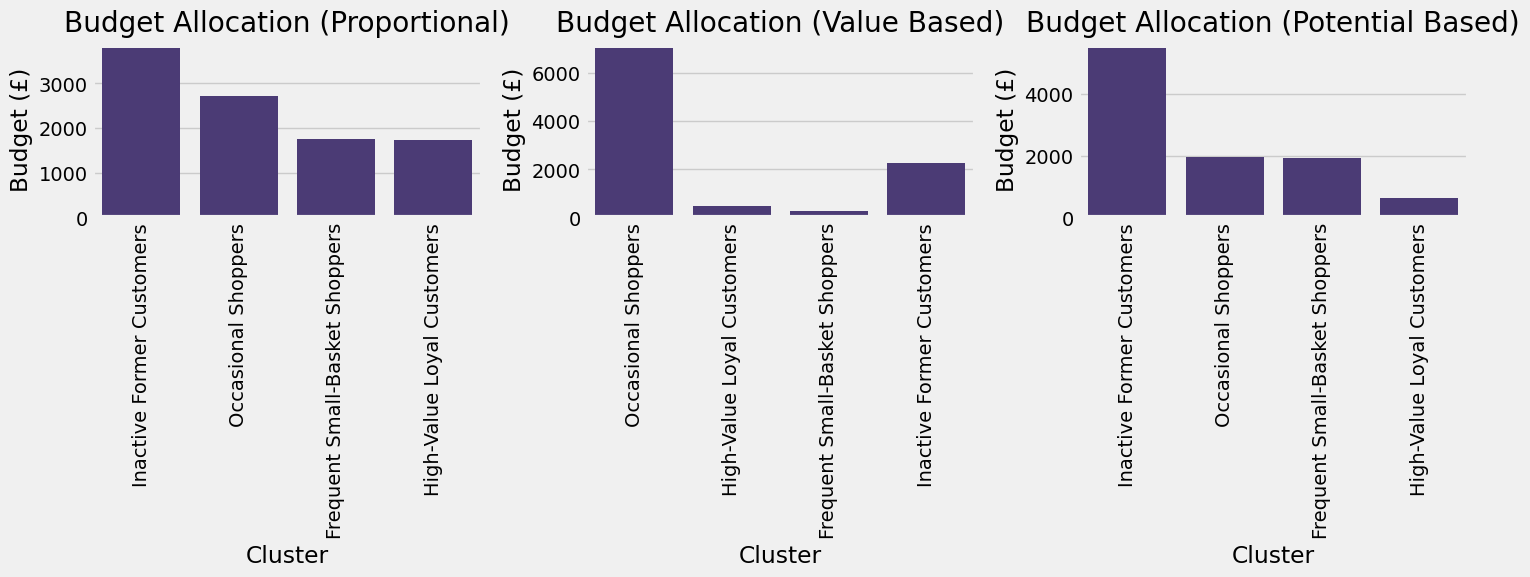


Expected ROI from Potential-based Budget Allocation:
                          Segment    Budget  Current Revenue  \
0       Inactive Former Customers  3.793267      1107954.973   
1             Occasional Shoppers  1.896633      3470137.891   
2  Frequent Small-Basket Shoppers  2.844950       125340.070   
3      High-Value Loyal Customers  0.948317       234059.270   

   Expected Increase            ROI  
0       332386.49190   87624.388927  
1       520520.68365  274443.530454  
2        25068.01400    8810.406921  
3        11702.96350   12339.775011  


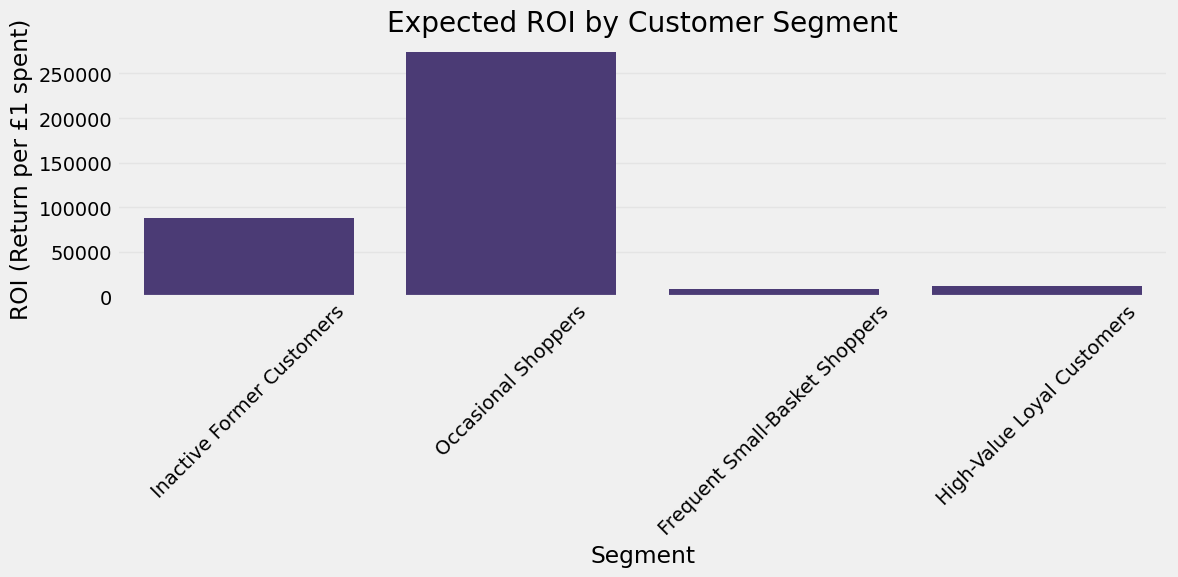

In [27]:
# Estimate overall revenue impact of improved targeting based on segments
total_revenue = customer_metrics['Monetary'].sum()
avg_revenue_per_customer = customer_metrics['Monetary'].mean()
customers_count = len(customer_metrics)

# Assumptions based on industry benchmarks
target_improvement_rates = {
    0: 0.15,  # 15% improvement for Occasional Shoppers
    1: 0.05,  # 5% improvement for High-Value Loyal Customers (already good)
    2: 0.20,  # 20% improvement for Frequent Small-Basket Shoppers
    3: 0.30,  # 30% improvement for Inactive Former Customers (high potential)
}

# Calculate potential revenue increase
potential_increase = 0
for cluster_id, improvement_rate in target_improvement_rates.items():
    cluster_data = customer_metrics[customer_metrics['Cluster_KMeans'] == cluster_id]
    cluster_revenue = cluster_data['Monetary'].sum()
    cluster_increase = cluster_revenue * improvement_rate
    potential_increase += cluster_increase
    
    print(f"Potential increase from {cluster_names[cluster_id]}: £{cluster_increase:.2f}")

print(f"\nTotal current revenue: £{total_revenue:.2f}")
print(f"Potential additional revenue: £{potential_increase:.2f}")
print(f"Percentage increase: {(potential_increase / total_revenue * 100):.1f}%")

# Create a function to calculate optimal marketing budget allocation based on segments
def allocate_marketing_budget(total_budget, customer_data, cluster_column, strategy='proportional'):
    """
    Allocate marketing budget across customer segments.
    
    Parameters:
    - total_budget: Total marketing budget in currency units
    - customer_data: DataFrame with customer data including clusters
    - cluster_column: Column name containing cluster assignments
    - strategy: Budget allocation strategy ('proportional', 'value_based', 'potential_based')
    
    Returns:
    - Dictionary with budget allocation by cluster
    """
    cluster_counts = customer_data[cluster_column].value_counts()
    cluster_values = customer_data.groupby(cluster_column)['Monetary'].sum()
    
    if strategy == 'proportional':
        # Allocate budget proportionally to segment sizes
        allocation_weights = cluster_counts / cluster_counts.sum()
    
    elif strategy == 'value_based':
        # Allocate budget proportionally to segment value
        allocation_weights = cluster_values / cluster_values.sum()
    
    elif strategy == 'potential_based':
        # Allocate budget based on improvement potential (example)
        potential_weights = {
            0: 2,  # Medium potential
            1: 1,  # Low potential (already valuable)
            2: 3,  # High potential
            3: 4,  # Very high potential
        }
        weighted_counts = cluster_counts.copy()
        for cluster_id, weight in potential_weights.items():
            if cluster_id in weighted_counts.index:
                weighted_counts[cluster_id] *= weight
        
        allocation_weights = weighted_counts / weighted_counts.sum()
    
    else:
        raise ValueError("Invalid strategy. Choose 'proportional', 'value_based', or 'potential_based'")
    
    # Calculate budget allocation
    budget_allocation = {
        cluster_id: total_budget * weight
        for cluster_id, weight in allocation_weights.items()
    }
    
    # Calculate per-customer budget in each segment
    per_customer_budget = {
        cluster_id: budget / cluster_counts[cluster_id]
        for cluster_id, budget in budget_allocation.items()
    }
    
    return budget_allocation, per_customer_budget

# Example: Allocate a marketing budget of £10,000
total_marketing_budget = 10000

# Compare different allocation strategies
strategies = ['proportional', 'value_based', 'potential_based']

plt.figure(figsize=(15, 6))

for i, strategy in enumerate(strategies):
    budget_allocation, per_customer_budget = allocate_marketing_budget(
        total_marketing_budget, customer_metrics, 'Cluster_KMeans', strategy
    )
    
    # Convert to DataFrames for easier plotting
    budget_df = pd.DataFrame({
        'Cluster': [cluster_names[k] for k in budget_allocation.keys()],
        'Budget': list(budget_allocation.values())
    })
    
    per_customer_df = pd.DataFrame({
        'Cluster': [cluster_names[k] for k in per_customer_budget.keys()],
        'Budget Per Customer': list(per_customer_budget.values())
    })
    
    # Plot budget allocation
    plt.subplot(1, 3, i+1)
    sns.barplot(x='Cluster', y='Budget', data=budget_df)
    plt.title(f'Budget Allocation ({strategy.replace("_", " ").title()})')
    plt.xticks(rotation=90)
    plt.ylabel('Budget (£)')
    plt.tight_layout()

plt.show()

# Calculate expected ROI based on allocated budget
def calculate_expected_roi(budget_allocation, improvement_rates, customer_data, cluster_column='Cluster_KMeans'):
    """
    Calculate expected ROI from marketing budget allocation.
    
    Parameters:
    - budget_allocation: Dictionary with budget allocated to each cluster
    - improvement_rates: Dictionary with expected revenue improvement rates for each cluster
    - customer_data: DataFrame with customer data
    - cluster_column: Column name containing cluster assignments
    
    Returns:
    - Dictionary with expected ROI metrics by cluster
    """
    roi_metrics = {}
    
    for cluster_id, budget in budget_allocation.items():
        cluster_data = customer_data[customer_data[cluster_column] == cluster_id]
        current_revenue = cluster_data['Monetary'].sum()
        expected_increase = current_revenue * improvement_rates[cluster_id]
        roi = (expected_increase - budget) / budget if budget > 0 else 0
        
        roi_metrics[cluster_id] = {
            'budget': budget,
            'current_revenue': current_revenue,
            'expected_increase': expected_increase,
            'roi': roi
        }
    
    return roi_metrics

# Calculate expected ROI for potential-based allocation
_, potential_allocation = allocate_marketing_budget(
    total_marketing_budget, customer_metrics, 'Cluster_KMeans', 'potential_based'
)

roi_metrics = calculate_expected_roi(potential_allocation, target_improvement_rates, customer_metrics)

# Display ROI metrics
roi_df = pd.DataFrame({
    'Segment': [cluster_names[k] for k in roi_metrics.keys()],
    'Budget': [m['budget'] for m in roi_metrics.values()],
    'Current Revenue': [m['current_revenue'] for m in roi_metrics.values()],
    'Expected Increase': [m['expected_increase'] for m in roi_metrics.values()],
    'ROI': [m['roi'] for m in roi_metrics.values()],
})

print("\nExpected ROI from Potential-based Budget Allocation:")
print(roi_df)

# Visualize ROI
plt.figure(figsize=(12, 6))
sns.barplot(x='Segment', y='ROI', data=roi_df)
plt.title('Expected ROI by Customer Segment')
plt.ylabel('ROI (Return per £1 spent)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.9 Summary of Customer Segmentation Findings

In [28]:
# Create a comprehensive summary of findings
summary = f"""
# E-commerce Customer Segmentation Summary

## Analysis Overview
- Dataset: Online Retail II dataset containing {df.shape[0]} transactions
- Focus: UK market with {df_uk.shape[0]} transactions
- Customers analyzed: {customers_count} unique customers
- Total revenue: £{total_revenue:.2f}
- Analysis period: {df_uk['InvoiceDate'].min().date()} to {df_uk['InvoiceDate'].max().date()}

## Segmentation Results
Our clustering analysis identified {optimal_k} distinct customer segments:

"""

for cluster_id, name in cluster_names.items():
    cluster_data = customer_metrics[customer_metrics['Cluster_KMeans'] == cluster_id]
    size = len(cluster_data)
    percentage = size / len(customer_metrics) * 100
    recency = cluster_data['Recency'].mean()
    frequency = cluster_data['Frequency'].mean()
    monetary = cluster_data['Monetary'].mean()
    
    summary += f"""
### {name} (Segment {cluster_id})
- **Size**: {size} customers ({percentage:.1f}% of total)
- **Characteristics**: 
  - Recency: {recency:.1f} days since last purchase
  - Frequency: {frequency:.1f} purchases on average
  - Monetary: £{monetary:.2f} total spend on average
- **Behavioral pattern**: {cluster_analysis.loc[cluster_id, 'PrefDay']} shoppers, typically around {int(cluster_analysis.loc[cluster_id, 'PrefHour']):02d}:00
- **Primary marketing objective**: {"Retention and upselling" if cluster_id == 1 else "Frequency increase" if cluster_id == 0 else "Basket value increase" if cluster_id == 2 else "Reactivation"}
"""

summary += """
## Business Recommendations

1. **Segment-specific marketing strategies**:
   - Target each segment with tailored messaging and offers
   - Allocate marketing budget based on segment potential
   - Design communication timing based on preferred shopping days/hours

2. **Customer experience enhancements**:
   - Personalize website experience based on segment
   - Implement VIP program for high-value customers
   - Simplify checkout for frequent small-basket shoppers

3. **Product recommendations**:
   - Use segment-specific recommendation engines
   - Cross-sell and upsell based on segment purchasing patterns
   - Introduce new product lines based on segment preferences

4. **Customer retention initiatives**:
   - Implement targeted loyalty programs for each segment
   - Design reactivation campaigns for inactive customers
   - Create tiered benefits based on customer value and potential

## Implementation Plan
1. Integrate segmentation model into CRM system
2. Develop segment-specific marketing campaigns 
3. Establish monitoring system to track segment changes
4. Schedule quarterly re-segmentation to capture evolving patterns
5. Create feedback loops to measure campaign effectiveness by segment
"""

# Print summary
print(summary)


# E-commerce Customer Segmentation Summary

## Analysis Overview
- Dataset: Online Retail II dataset containing 397885 transactions
- Focus: UK market with 354321 transactions
- Customers analyzed: 3818 unique customers
- Total revenue: £4937492.20
- Analysis period: 2010-12-01 to 2011-12-09

## Segmentation Results
Our clustering analysis identified 4 distinct customer segments:


### Occasional Shoppers (Segment 0)
- **Size**: 1037 customers (27.2% of total)
- **Characteristics**: 
  - Recency: 31.1 days since last purchase
  - Frequency: 8.3 purchases on average
  - Monetary: £3346.32 total spend on average
- **Behavioral pattern**: Thursday shoppers, typically around 12:00
- **Primary marketing objective**: Frequency increase

### High-Value Loyal Customers (Segment 1)
- **Size**: 660 customers (17.3% of total)
- **Characteristics**: 
  - Recency: 259.6 days since last purchase
  - Frequency: 1.3 purchases on average
  - Monetary: £354.64 total spend on average
- **Behavioral patt

## Final Comparison: Three Machine Learning Paradigms

### Comparing Regression, Classification, and Clustering

Each of the case studies explored a different machine learning paradigm:

1. **Regression (Housing Price Prediction)**:
   - **Goal**: Predict a continuous value (house prices)
   - **Approach**: Supervised learning with labeled data
   - **Metrics**: RMSE, R², Mean Absolute Error
   - **Key models**: Linear Regression, Random Forest Regressor
   - **Application**: Price forecasting, value estimation

2. **Classification (Customer Churn Prediction)**:
   - **Goal**: Predict a categorical outcome (churn/no churn)
   - **Approach**: Supervised learning with labeled data
   - **Metrics**: Accuracy, Precision, Recall, F1-Score, AUC-ROC
   - **Key models**: Logistic Regression, Random Forest Classifier
   - **Application**: Binary or multi-class prediction problems

3. **Clustering (E-commerce Customer Segmentation)**:
   - **Goal**: Discover natural groupings in data
   - **Approach**: Unsupervised learning without labels
   - **Metrics**: Silhouette Score, Calinski-Harabasz Index
   - **Key models**: K-means, DBSCAN, Hierarchical Clustering
   - **Application**: Customer segmentation, anomaly detection

### When to Use Each Approach

- **Use regression** when predicting numerical values like prices, sales figures, or any continuous variable.
- **Use classification** when predicting categories or classes, such as customer churn, spam detection, or disease diagnosis.
- **Use clustering** when you want to discover hidden patterns or groupings without predefined labels, like market segmentation or customer behavior analysis.

### How These Methods Complement Each Other

In real-world business applications, these three approaches often work together:

1. **Clustering → Classification**:
   - First segment customers using clustering
   - Then build segment-specific classification models to predict behaviors within each segment

2. **Classification + Regression**:
   - Use classification to determine if a customer will purchase
   - Then use regression to predict how much they will spend

3. **Clustering + Regression**:
   - Group similar properties using clustering
   - Build cluster-specific regression models for more accurate price predictions

The three paradigms represent core techniques in the machine learning toolkit, each addressing different types of problems but often working together as part of comprehensive analytics solutions.